In [1]:
import logging
import warnings
import os
import sys
import contextlib
import warnings
from sklearn.exceptions import ConvergenceWarning
from statsmodels.tools.sm_exceptions import ValueWarning,ConvergenceWarning

logging.basicConfig(level=logging.ERROR)
warnings.filterwarnings("ignore")
os.environ["MLFLOW_ENABLE_ARTIFACTS_PROGRESS_BAR"] = "false"

@contextlib.contextmanager
def suppress_stdout():
    with open(os.devnull, "w") as devnull:
        old_stdout = sys.stdout
        sys.stdout = devnull
        try:
            yield
        finally:
            sys.stdout = old_stdout

#with suppress_stdout():
#   call_function()


warnings.simplefilter("ignore", ValueWarning)
warnings.simplefilter("ignore", ConvergenceWarning)


os.environ["PYTHONWARNINGS"] = "ignore"     # child processes (joblib) read this
warnings.filterwarnings("ignore")           # hide all categories in this process
logging.getLogger("py.warnings").setLevel(logging.ERROR)  # warnings routed via logging

In [2]:
project_root = os.getcwd()
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import os
import pandas as pd
import numpy as np
from sklearn.model_selection import RepeatedKFold, GridSearchCV, RandomizedSearchCV, cross_val_score
from hyperopt import partial, anneal, tpe, rand, mix, STATUS_OK, Trials, hp, fmin, STATUS_OK,STATUS_FAIL, space_eval
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor
from sklearn.preprocessing import MinMaxScaler
from sklearn.feature_selection import SelectKBest
from sklearn.feature_selection import f_regression,mutual_info_regression
from sklearn.compose import ColumnTransformer
from sklearn.metrics import make_scorer,mean_squared_error
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.model_selection import cross_validate
import matplotlib.patheffects as path_effects
from itertools import combinations
from sklearn.feature_selection import SelectFromModel
from sklearn.base import BaseEstimator, TransformerMixin
import pickle
from sklearn.linear_model import Lasso
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error,root_mean_squared_error
from sklearn.cross_decomposition import PLSRegression
from sklearn.linear_model import LinearRegression
from sklearn.decomposition import PCA
from sklearn.svm import SVR
from sklearn.metrics import mutual_info_score
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import TransformedTargetRegressor
from functools import partial
from hyperopt import hp, fmin, Trials, pyll
from hyperopt.base import miscs_update_idxs_vals
from hyperopt.pyll.base import dfs, as_apply
from hyperopt.pyll.stochastic import implicit_stochastic_symbols
from hyperopt.pyll import scope
import sys
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import make_scorer
from mlxtend.feature_selection import SequentialFeatureSelector as SFS
from sklearn.feature_selection import VarianceThreshold
from mlxtend.plotting import plot_sequential_feature_selection as plot_sfs
import matplotlib.ticker as plticker
from mlxtend.evaluate.time_series import (
    GroupTimeSeriesSplit,
    plot_splits,
    print_cv_info,
    print_split_info,
)
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import Ridge
import plotly.express as px
import plotly.graph_objects as go
from scipy.signal import savgol_filter
from pykalman import KalmanFilter
from sklearn.model_selection import TimeSeriesSplit
from sklearn.feature_selection import SequentialFeatureSelector
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from sklearn.covariance import LedoitWolf
from scipy.stats import norm
from sklearn.neighbors import KernelDensity
from sklearn.covariance import LedoitWolf
from scipy.optimize import minimize, Bounds, NonlinearConstraint,differential_evolution
from scipy.stats import t as student_t
from scipy.special import gammaln
import matplotlib.cm as cm


In [3]:
# create a folder for the script files
script_folder = 'src'
os.makedirs(script_folder, exist_ok=True)
print(script_folder, 'folder created')

src folder created


In [4]:
sns.set(rc={"figure.figsize":(12, 4)})
sns.set_style('whitegrid')
sns.set_context('notebook')

# Utility functions

In [633]:
def _project_to_pd(R, eps=1e-8):
    """Eigenvalue-clipping PD projection; renormalize diag to 1."""
    R = (R + R.T) / 2.0
    w, V = np.linalg.eigh(R)
    w = np.clip(w, eps, None)
    R_pd = (V * w) @ V.T
    R_pd = (R_pd + R_pd.T) / 2.0
    D = np.sqrt(np.clip(np.diag(R_pd), eps, None))
    return R_pd / np.outer(D, D)

def _log_mv_t_density(Z, R_inv, logdet_R, nu):
    """
    log f_d^t(z; 0, R, nu) for rows of Z.
    f_d^t(z) ∝ |R|^{-1/2} (1 + z^T R^{-1} z / nu)^(-(nu+d)/2)
    """
    Z = np.atleast_2d(Z)
    d = Z.shape[1]
    Q = np.einsum("...i,ij,...j->...", Z, R_inv, Z)
    c = gammaln((nu + d) / 2) - gammaln(nu / 2) - (d / 2) * np.log(nu * np.pi) - 0.5 * logdet_R
    return c - 0.5 * (nu + d) * np.log1p(Q / nu)

def _log_univ_t_density(z, nu):
    """sum over dims of log f_1^t(z_i; 0, 1, nu)."""
    z = np.atleast_2d(z)
    d = z.shape[1]
    c = d * (gammaln((nu + 1) / 2) - gammaln(nu / 2) - 0.5 * np.log(nu * np.pi))
    return c - 0.5 * (nu + 1) * np.sum(np.log1p((z ** 2) / nu), axis=1)

class GaussianCopulaContinuous:
    """
    Student-t copula with KDE/ECDF marginals (compatible with your ContinuousMarginal).

    Parameters
    ----------
    bandwidth : float | None
        Passed to the marginal estimator.
    eps : float
        Clipping for PIT endpoints.
    random_state : int | None
    nu : float | "auto"
        Degrees of freedom for the t-copula; if "auto", selected by pseudo-MLE.
    nu_grid : iterable[float]
        Candidate ν values when nu="auto".
    marginal_cls : class
        Class to use for marginals (defaults to your ContinuousMarginal).
    jitter_frac : float
        Tiny jitter (fraction of min step) applied during U-transform to break ties.
    """
    def __init__(self, bandwidth=None, eps=1e-6, random_state=None,
                 nu="auto", nu_grid=(2, 3, 4, 5, 7, 10, 15, 20, 30, 50),
                 marginal_cls=ContinuousMarginal, jitter_frac=0.0):
        self.bandwidth = bandwidth
        self.eps = eps
        self.random_state = random_state
        self.nu = nu
        self.nu_grid = tuple(nu_grid)
        self.marginal_cls = marginal_cls
        self.jitter_frac = jitter_frac

        self.columns_ = None
        self.marginals_ = None
        self.R_ = None
        self.R_inv_ = None
        self.logdet_R_ = None
        self.nu_ = None
        self._rng = np.random.default_rng(random_state)

    # ---------- fit ----------
    def fit(self, X: pd.DataFrame):
        if not np.all([pd.api.types.is_numeric_dtype(X[c]) for c in X.columns]):
            raise ValueError("All columns must be numeric (continuous).")

        df = X.copy()
        self.columns_ = list(df.columns)
        for c in self.columns_:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())

        # marginals
        self.marginals_ = {
            c: self.marginal_cls(self.bandwidth, self.eps).fit(df[c].to_numpy())
            for c in self.columns_
        }

        # U-transform (with optional tiny jitter to break ties)
        U = []
        for c in self.columns_:
            x = df[c].to_numpy()
            if self.jitter_frac > 0 and np.unique(x).size < x.size:
                # data-scaled jitter
                vals = np.unique(np.sort(x))
                diffs = np.diff(vals)
                step = float(np.min(diffs[diffs > 0])) if np.any(diffs > 0) else float(np.std(x) or 1.0)
                sigma = max(1e-12, self.jitter_frac * step)
                x = x + self._rng.normal(0.0, sigma, size=x.size)
            U.append(self.marginals_[c].cdf(x))
        U = np.column_stack(U)

        # choose ν and estimate R by pseudo-MLE
        if self.nu == "auto":
            best = None
            for nu_cand in self.nu_grid:
                Z = student_t.ppf(np.clip(U, self.eps, 1 - self.eps), df=nu_cand)
                R, loglik = self._estimate_R_and_ll(Z, nu_cand)
                if (best is None) or (loglik > best[1]):
                    best = (nu_cand, loglik, R)
            self.nu_ = best[0]
            self.R_ = best[2]
        else:
            self.nu_ = float(self.nu)
            Z = student_t.ppf(np.clip(U, self.eps, 1 - self.eps), df=self.nu_)
            self.R_, _ = self._estimate_R_and_ll(Z, self.nu_)

        # cache inverses/logdet
        self.R_inv_ = np.linalg.inv(self.R_)
        self.logdet_R_ = float(np.linalg.slogdet(self.R_)[1])
        return self

    def _estimate_R_and_ll(self, Z, nu):
        # shrinked covariance -> correlation
        lw = LedoitWolf().fit(Z)
        Sigma = lw.covariance_
        d = np.sqrt(np.clip(np.diag(Sigma), 1e-12, None))
        R = Sigma / np.outer(d, d)
        R = _project_to_pd(R)

        Rin = np.linalg.inv(R)
        logdet = float(np.linalg.slogdet(R)[1])
        # pseudo log-likelihood of copula: log f_d^t - sum log f_1^t
        ll = _log_mv_t_density(Z, Rin, logdet, nu) - _log_univ_t_density(Z, nu)
        return R, float(np.sum(ll))

    # ---------- scoring ----------
    def score_samples(self, X: pd.DataFrame) -> np.ndarray:
        self._check_fitted()
        df = X[self.columns_].copy()
        for c in self.columns_:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())

        U = []
        log_marg = []
        for c in self.columns_:
            x = df[c].to_numpy()
            U.append(self.marginals_[c].cdf(x))
            log_marg.append(self.marginals_[c].log_pdf(x))
        U = np.column_stack(U)
        Z = student_t.ppf(np.clip(U, self.eps, 1 - self.eps), df=self.nu_)
        log_c = _log_mv_t_density(Z, self.R_inv_, self.logdet_R_, self.nu_) - _log_univ_t_density(Z, self.nu_)
        log_m = np.column_stack(log_marg).sum(axis=1)
        return log_c + log_m

    # ---------- sampling ----------
    def sample(self, n: int) -> pd.DataFrame:
        self._check_fitted()
        d = len(self.columns_)
        # sample multivariate t: y ~ N(0,R), g ~ chi2_nu, z = y / sqrt(g/nu)
        L = np.linalg.cholesky(self.R_)
        y = self._rng.standard_normal(size=(n, d)) @ L.T
        g = self._rng.chisquare(self.nu_, size=n)
        Z = y / np.sqrt(g[:, None] / self.nu_)
        U = student_t.cdf(Z, df=self.nu_)
        data = {c: self.marginals_[c].inv_cdf(U[:, j]) for j, c in enumerate(self.columns_)}
        return pd.DataFrame(data, columns=self.columns_)

    def _check_fitted(self):
        if self.R_ is None or self.marginals_ is None or self.nu_ is None:
            raise RuntimeError("Model not fitted. Call fit(X) first.")
        

    def _median_for(self, c: str) -> float:
        """
        Return the training-time median for column c using the fitted marginal.
        Safe because the marginal inverse CDF at 0.5 equals the median.
        """
        return float(self.marginals_[c].inv_cdf(np.array([0.5]))[0])

    # ---------- conditional sampling in t-copula ----------
    def conditional_sample(self, target: str, given_df: pd.DataFrame | dict, n: int = 50_000) -> np.ndarray:
        """
        Sample X_target | X_given using the t-copula conditionals:
          1) transform given X -> U -> Z via the fitted marginals and t-ppf (df=self.nu_)
          2) compute conditional (mu, s2, nu') in Z-space
          3) draw z ~ t_{nu'}(mu, s) and map to u = T_{nu}(z)
          4) return inv_cdf_target(u)
        """
        self._check_fitted()
        if target not in self.columns_:
            raise KeyError(f"Unknown target '{target}'. Must be one of {self.columns_}.")

        # --- collect and order the "given" variables that are present ---
        if isinstance(given_df, dict):
            given_df = pd.DataFrame([given_df])
        if not isinstance(given_df, pd.DataFrame) or len(given_df) == 0:
            raise ValueError("given_df must be a non-empty dict or DataFrame with one row.")

        given_df = given_df.iloc[[0]]  # first row only
        # use any columns that are in the copula (except target) and provided by user
        g_cols = [c for c in self.columns_ if c != target and c in given_df.columns]
        if len(g_cols) == 0:
            # unconditional: Z_j ~ t_nu(0,1)
            z = self._rng.standard_t(df=self.nu_, size=n)
            u = student_t.cdf(z, df=self.nu_)
            return self.marginals_[target].inv_cdf(u)

        # --- transform given X -> Z using fitted marginals and df=self.nu_ ---
        z_g_list = []
        for c in g_cols:
            x = float(pd.to_numeric(given_df[c], errors="coerce").fillna(self._median_for(c)).values[0])
            u = self.marginals_[c].cdf(np.array([x]))
            z = student_t.ppf(np.clip(u, self.eps, 1 - self.eps), df=self.nu_)
            z_g_list.append(float(z[0]))
        z_g = np.asarray(z_g_list, dtype=float)

        # --- build correlation blocks ---
        j = self.columns_.index(target)
        g_idx = [self.columns_.index(c) for c in g_cols]

        R = self.R_
        R_jj = float(R[j, j])                   # should be 1.0 after normalization
        R_jg = R[j, :][g_idx].reshape(1, -1)    # (1, k)
        R_gj = R[:, j][g_idx].reshape(-1, 1)    # (k, 1)
        R_gg = R[np.ix_(g_idx, g_idx)]          # (k, k)

        # --- conditional parameters in Z-space ---
        k = len(g_idx)
        Rgg_inv = np.linalg.inv(R_gg)
        beta = R_jg @ Rgg_inv                   # (1, k)
        mu = float(beta @ z_g)                  # scalar
        S = float(R_jj - beta @ R_gj)           # scalar >= 0
        quad = float(z_g @ Rgg_inv @ z_g)       # z_g^T R_gg^{-1} z_g
        nu_prime = self.nu_ + k
        scale2 = ((self.nu_ + quad) / nu_prime) * max(S, 0.0)
        scale = float(np.sqrt(max(scale2, 0.0)))

        # --- sample Z_j | Z_g=z_g then map through t-CDF with ORIGINAL nu ---
        z_samples = mu + scale * self._rng.standard_t(df=nu_prime, size=n)
        u_samples = student_t.cdf(z_samples, df=self.nu_)
        return self.marginals_[target].inv_cdf(u_samples)

    def conditional_summary(
        self,
        target: str,
        given_df: pd.DataFrame | dict,
        n: int = 100_000,
        quantiles=(0.05, 0.5, 0.95),
    ) -> dict:
        """
        Monte Carlo summary for X_target | X_given under the fitted t-copula.
        """
        xs = self.conditional_sample(target, given_df, n=n)
        out = {
            "mean": float(np.mean(xs)),
            "std": float(np.std(xs, ddof=1)),
        }
        for q in quantiles:
            out[f"q{int(round(q*100)):02d}"] = float(np.quantile(xs, q))
        return out



df_fixed = pd.DataFrame([{"Current_basis_weight": 120.0, "grammage":120}])

df_hist=turnup[df_fixed.columns]
df_hist.loc[(df_hist["Current_basis_weight"] < df_hist["grammage"]-3), "Current_basis_weight"] = np.nan
df_hist.loc[(df_hist["Current_basis_weight"] > df_hist["grammage"]+3), "Current_basis_weight"] = np.nan

joint = GaussianCopulaContinuous(random_state=42,nu="auto",jitter_frac=0.1).fit(turnup[df_fixed.columns])

lo, hi, profile = conditional_bounds_from_joint(
        "Current_basis_weight",
        df_hist=df_hist,
        joint=joint,
        df_fixed=df_fixed
    )

In [5]:
def ewm_reset(s):
    out = s.ewm(halflife="120min", times=s.index, adjust=True).mean()
    if len(s) >= 2:
        out.iloc[0] = (s.iloc[0] + s.iloc[1]) / 2.0   # softer start
    return out

class ContinuousMarginal:
    def __init__(self, bandwidth: float | None = None, eps: float = 1e-6):
        self.bandwidth = bandwidth
        self.eps = eps
        self.x_ = None
        self.cdf_y_ = None
        self.kde_ = None

    def fit(self, x: np.ndarray):
        x = np.asarray(x, dtype=float)
        x = x[np.isfinite(x)]
        if x.size < 5:
            raise ValueError("Not enough data to fit marginal.")
        xs = np.sort(x)
        uniq, counts = np.unique(xs, return_counts=True)
        cum = np.cumsum(counts)
        mids = (cum - counts/2) / xs.size
        self.x_, self.cdf_y_ = uniq, mids
        if self.bandwidth is None:
            std = np.std(x, ddof=1)
            bw = 1.06 * std * x.size ** (-1/5) if std > 0 else 0.1
        else:
            bw = float(self.bandwidth)
        self.kde_ = KernelDensity(kernel="gaussian", bandwidth=max(bw, 1e-3)).fit(x[:, None])
        return self

    def cdf(self, x: np.ndarray) -> np.ndarray:
        u = np.interp(x, self.x_, self.cdf_y_, left=self.cdf_y_[0], right=self.cdf_y_[-1])
        return np.clip(u, self.eps, 1 - self.eps)

    def inv_cdf(self, u: np.ndarray) -> np.ndarray:
        u = np.clip(u, self.eps, 1 - self.eps)
        return np.interp(u, self.cdf_y_, self.x_, left=self.x_[0], right=self.x_[-1])

    def log_pdf(self, x: np.ndarray) -> np.ndarray:
        return self.kde_.score_samples(np.asarray(x, dtype=float)[:, None])


class GaussianCopulaContinuous:
    def __init__(self, bandwidth: float | None = None, random_state: int | None = None, eps: float = 1e-6):
        self.bandwidth = bandwidth
        self.random_state = random_state
        self.eps = eps
        self.columns_ = None
        self.marginals_ = None
        self.R_ = None
        self.R_inv_ = None
        self.logdet_R_ = None
        self._rng = np.random.default_rng(random_state)

    def fit(self, X: pd.DataFrame):
        if not np.all([pd.api.types.is_numeric_dtype(X[c]) for c in X.columns]):
            raise ValueError("All columns must be numeric.")
        df = X.copy()
        self.columns_ = list(df.columns)
        for c in self.columns_:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())
        self.marginals_ = {c: ContinuousMarginal(self.bandwidth, self.eps).fit(df[c].to_numpy())
                           for c in self.columns_}
        U = np.column_stack([self.marginals_[c].cdf(df[c].to_numpy()) for c in self.columns_])
        Z = norm.ppf(np.clip(U, self.eps, 1 - self.eps))
        lw = LedoitWolf().fit(Z)
        Sigma = lw.covariance_
        d = np.sqrt(np.diag(Sigma)); d[d == 0] = 1.0
        R = Sigma / np.outer(d, d)
        R = (R + R.T) / 2.0
        self.R_ = R
        self.R_inv_ = np.linalg.inv(R)
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            raise RuntimeError("Estimated correlation not PD.")
        self.logdet_R_ = logdet
        return self

    def _check(self):
        if self.R_ is None or self.marginals_ is None or self.columns_ is None:
            raise RuntimeError("Model not fitted.")

    def _to_Z(self, X: pd.DataFrame) -> np.ndarray:
        df = X[self.columns_].copy()
        for c in self.columns_:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())
        U = np.column_stack([self.marginals_[c].cdf(df[c].to_numpy()) for c in self.columns_])
        return norm.ppf(np.clip(U, self.eps, 1 - self.eps))

    def _log_copula_density(self, Z: np.ndarray) -> np.ndarray:
        q1 = np.einsum("...i,ij,...j->...", Z, self.R_inv_, Z)
        q0 = np.einsum("...i,...i->...", Z, Z)
        return -0.5 * self.logdet_R_ - 0.5 * (q1 - q0)

    def score_samples(self, X: pd.DataFrame) -> np.ndarray:
        self._check()
        Z = self._to_Z(X)
        log_m = 0.0
        for c in self.columns_:
            log_m += self.marginals_[c].log_pdf(np.asarray(X[c], dtype=float))
        return self._log_copula_density(Z) + log_m

    def sample(self, n: int) -> pd.DataFrame:
        self._check()
        L = np.linalg.cholesky(self.R_)
        Z = self._rng.standard_normal(size=(n, len(self.columns_))) @ L.T
        U = norm.cdf(Z)
        data = {c: self.marginals_[c].inv_cdf(U[:, j]) for j, c in enumerate(self.columns_)}
        return pd.DataFrame(data, columns=self.columns_)

    # ---- conditional utilities ----
    def conditional_params(self, target: str, given_df: pd.DataFrame | dict) -> tuple[float, float]:
        self._check()
        if isinstance(given_df, dict):
            given_df = pd.DataFrame([given_df])
        if len(given_df) != 1:
            raise ValueError("given_df must be single-row.")
        cols = self.columns_
        if target not in cols:
            raise KeyError(f"Target '{target}' not in columns.")
        t_idx = cols.index(target)
        given_cols = [c for c in cols if c in given_df.columns and c != target]
        if not given_cols:
            return 0.0, 1.0
        g_idx = [cols.index(c) for c in given_cols]
        tpl = pd.Series({c: given_df.iloc[0][c] if c in given_cols else 0.0 for c in cols}, dtype=float)
        Z_all = self._to_Z(pd.DataFrame([tpl], columns=cols))
        z_g = Z_all[0, g_idx]
        R = self.R_
        R_gg = R[np.ix_(g_idx, g_idx)]
        R_tg = R[t_idx, g_idx]
        R_gg_inv = np.linalg.inv(R_gg)
        mu = float(R_tg @ R_gg_inv @ z_g)
        var = float(1.0 - R_tg @ R_gg_inv @ R_tg.T)
        return mu, max(var, 1e-9)

    def conditional_sample(self, target: str, given_df: pd.DataFrame | dict, n: int = 50_000) -> np.ndarray:
        mu, var = self.conditional_params(target, given_df)
        z = np.random.default_rng().normal(loc=mu, scale=np.sqrt(var), size=n)
        u = norm.cdf(z)
        return self.marginals_[target].inv_cdf(u)

    def conditional_summary(self, target: str, given_df: pd.DataFrame | dict, n: int = 100_000,
                            quantiles=(0.05, 0.5, 0.95)) -> dict:
        xs = self.conditional_sample(target, given_df, n=n)
        out = {"mean": float(np.mean(xs)), "std": float(np.std(xs, ddof=1))}
        for q in quantiles:
            out[f"q{int(q*100):02d}"] = float(np.quantile(xs, q))
        return out

def _numeric(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy().apply(pd.to_numeric, errors="coerce")
    return df.fillna(df.median(numeric_only=True))

def model_feature_names(model, fallback_cols) -> list[str]:
    if hasattr(model, "feature_names_in_"):
        return list(model.feature_names_in_)
    if hasattr(model, "best_estimator_") and hasattr(model.best_estimator_, "feature_names_in_"):
        return list(model.best_estimator_.feature_names_in_)
    return list(fallback_cols)

def build_template(df_hist: pd.DataFrame, required_cols: list[str]) -> pd.Series:
    med = _numeric(df_hist).median(numeric_only=True)
    tpl = pd.Series(0.0, index=required_cols, dtype=float)
    common = med.index.intersection(tpl.index)
    tpl.loc[common] = med.loc[common].astype(float)
    return tpl
    
def conditional_bounds_from_joint(
    free_variable,
    df_hist: pd.DataFrame,
    joint: GaussianCopulaContinuous,
    df_fixed: pd.DataFrame | dict,
    q_bounds=(0.01, 0.99),
    grid_step: float = 0.01,
    safety_pad: float = 0.05,
    control_min: float | None = None,
    control_max: float | None = None,
    nonneg_control: bool = True,
    pre_expand: float = 0.0,                       # expand the grid range before quantiles
    post_expand: float = 0.0                       # expand final [lo,hi] after quantiles
) -> tuple[float, float, pd.DataFrame]:
    # normalize df_fixed
    if isinstance(df_fixed, dict):
        df_fixed = pd.DataFrame([df_fixed])
    df_fixed = df_fixed.iloc[[0]]

    # numeric history (for empirical envelope)
    df_num = df_hist.copy().apply(pd.to_numeric, errors="coerce")
    df_num = df_num.fillna(df_num.median(numeric_only=True))

    # wide empirical envelope for starch
    s_hist = pd.to_numeric(df_hist[free_variable], errors="coerce").dropna().to_numpy()
    
    if s_hist.size:
        q_lo_emp, q_hi_emp = np.quantile(s_hist, [0.01, 0.99])
    else:
        q_lo_emp, q_hi_emp = (0.0, 1.0)
   
    span = max(q_hi_emp - q_lo_emp, 1.0)
    lo_emp = q_lo_emp - safety_pad * span
    hi_emp = q_hi_emp + safety_pad * span
    if nonneg_control: lo_emp = max(0.0, lo_emp)
    if control_min is not None: lo_emp = max(lo_emp, float(control_min))
    if control_max is not None: hi_emp = min(hi_emp, float(control_max))
    if hi_emp <= lo_emp:
        hi_emp = lo_emp + max(1.0, grid_step)

    # slice along starch given df_fixed
    cols = joint.columns_
    tpl = df_num.median(numeric_only=True).reindex(cols, fill_value=0.0).astype(float)
    for c in df_fixed.columns.intersection(cols):
        v = pd.to_numeric(df_fixed.iloc[0][c], errors="coerce")
        if pd.notna(v): tpl[c] = float(v)

    # Pre-expand the grid window 
    base_span = hi_emp - lo_emp
    lo_grid = lo_emp - pre_expand * base_span
    hi_grid = hi_emp + pre_expand * base_span
    if nonneg_control: lo_grid = max(0.0, lo_grid)
    if control_min is not None: lo_grid = max(lo_grid, float(control_min))
    if control_max is not None: hi_grid = min(hi_grid, float(control_max))
    if hi_grid <= lo_grid: hi_grid = lo_grid + max(1.0, grid_step)    

    grid = np.arange(lo_emp, hi_emp + 1e-12, grid_step, dtype=float)
    rows = []
    for s in grid:
        r = tpl.copy(); r[free_variable] = float(s)
        rows.append(r)
    slice_df = pd.DataFrame(rows, columns=cols)

    # logpdf from joint (all columns)
    logpdf = np.asarray(joint.score_samples(slice_df), dtype=float)
    # stabilize & normalize to conditional pdf over starch
    logpdf_stab = logpdf - np.max(logpdf)
    unnorm = np.exp(logpdf_stab)
    if not np.isfinite(unnorm).any() or unnorm.sum() == 0:
        unnorm = np.ones_like(unnorm)
    Z = np.trapz(unnorm, grid)
    pdf = unnorm / max(Z, np.finfo(float).tiny)
    cdf = np.cumsum((pdf[:-1] + pdf[1:]) / 2 * np.diff(grid))
    cdf = np.concatenate([[0.0], cdf]); cdf = np.clip(cdf, 0.0, 1.0)

    q_lo, q_hi = q_bounds
    lo = float(np.interp(q_lo, cdf, grid))
    hi = float(np.interp(q_hi, cdf, grid))

    # post-expand the final bounds --------
    span_final = max(hi - lo, grid_step)
    
    lo_ext = lo - post_expand * span_final
    hi_ext = hi + post_expand * span_final
    # clamp to the grid range (so we don't exceed evaluated domain)
    lo_ext = max(lo_grid, lo_ext)
    hi_ext = min(hi_grid, hi_ext)

    profile = pd.DataFrame({free_variable: grid, "logpdf": logpdf, "pdf": pdf, "cdf": cdf})
    return lo_ext, hi_ext, profile

import numpy as np
from scipy.optimize import Bounds

def bounds_to_cobyla_constraints(bounds, n_vars=None):
    """
    Convert SciPy bounds (Bounds or list of (lo,hi)) into COBYLA-style
    inequality constraints g(x) >= 0.
    Returns a list suitable for minimize(..., method="COBYLA", constraints=...).
    """
    # Normalize to arrays lb, ub
    if isinstance(bounds, Bounds):
        lb = np.asarray(bounds.lb, dtype=float)
        ub = np.asarray(bounds.ub, dtype=float)
    else:
        # sequence of (lo, hi)
        pairs = list(bounds)
        lb = np.array([(-np.inf if lo is None else lo) for lo, _ in pairs], dtype=float)
        ub = np.array([( np.inf if hi is None else hi) for _, hi in pairs], dtype=float)

    if n_vars is None:
        n_vars = len(lb)

    cons = []
    for i in range(n_vars):
        lo = lb[i]
        hi = ub[i]
        if np.isfinite(lo):
            # x[i] - lo >= 0
            cons.append({"type": "ineq", "fun": (lambda i=i, lo=lo: lambda x: x[i] - lo)()})
        if np.isfinite(hi):
            # hi - x[i] >= 0
            cons.append({"type": "ineq", "fun": (lambda i=i, hi=hi: lambda x: hi - x[i])()})
    return cons


def data_aware_optimization(
    target_variable,
    target_value,
    control_variable,    
    joint: GaussianCopulaContinuous,
    df_hist: pd.DataFrame,
    df_fixed: pd.DataFrame | dict,
    costFunction,
    strength_model=None,
    lam_ll: float = 1e-5,     # weight for log-likelihood reward (cost units per nat)
    alpha_close: float = 0.0,      # >0 adds soft penalty to keep strength close to MIN_STRENGTH (e.g., 0.1)
    q_bounds=(0.01, 0.99),
    grid_step: float = 0.01,
    safety_pad: float = 0.05,
    control_min: float | None = None,
    control_max: float | None = None,
    nonneg_control: bool = True,
    pre_expand: float = 0.0,
    post_expand: float = 0.0,
    prefer_lower_if_flat: bool = True,   # NEW: choose lower feasible starch if objective flat
    flat_tol: float = 1e-8,              # NEW: tolerance for "flat" objective on prescan
    prescan_n: int = 201,                # NEW: grid size for prescan
    debug_check_control: bool = False,    # NEW: sanity-check what costFibreStarch sees
    method="SLSQP",
    strength_minimisation=True,
    verbose: bool = True
):
    # --- normalize df_fixed and ENSURE it does NOT pin control_variable ---
    if isinstance(df_fixed, dict):
        df_fixed = pd.DataFrame([df_fixed])
    df_fixed = df_fixed.iloc[[0]]

    required_cols = model_feature_names(strength_model, df_hist.columns)
    if 'y_L1' in required_cols and target_variable in df_fixed.columns:
        df_fixed=df_fixed.rename(columns={target_variable:'y_L1'})

    if control_variable in df_fixed.columns.to_list():
        initial_control =df_fixed[control_variable].values[0]
    else:
        initial_control = None
    
    xx = []
    yy = []

    df_fixed = df_fixed.drop(columns=[control_variable], errors="ignore")  # <-- critical

    # ---- get conditional starch bounds (with expand knobs) ----
    lo, hi, profile = conditional_bounds_from_joint(
        control_variable,
        df_hist=df_hist,
        joint=joint,
        df_fixed=df_fixed,
        q_bounds=q_bounds,
        grid_step=grid_step,
        safety_pad=safety_pad,
        control_min=control_min,
        control_max=control_max,
        nonneg_control=nonneg_control,
        pre_expand=pre_expand,
        post_expand=post_expand
    )
    bounds = Bounds([lo], [hi])

    if initial_control is None:
        initial_control = hi

    # ---- template row (fixed features + medians for others) ----
    joint_cols = joint.columns_
    df_num = df_hist.copy().apply(pd.to_numeric, errors="coerce")
    df_num = df_num.fillna(df_num.median(numeric_only=True))
    template = build_template(df_hist, required_cols)
    if isinstance(df_fixed, pd.Series):
        df_fixed = df_fixed.to_frame().T
    df_fixed = df_fixed.iloc[[0]]    
    
    for c in df_fixed.columns.intersection(required_cols):
        v = pd.to_numeric(df_fixed.iloc[0][c], errors="coerce")
        if pd.notna(v):
            template[c] = float(v)


    def make_row(s, joint_sample=False):
        if joint_sample:
            row = df_fixed.copy()
            row[control_variable] = float(s)
            return row
        else:    
            row = template.copy()
            row[control_variable] = float(s)
            if strength_model is None:
                return pd.DataFrame([row], columns=joint.columns_)
            else:
                return pd.DataFrame([row], columns=required_cols)
        
    # ---- strength predictor (ridge if provided; else copula conditional median) ----
    def predict_strength(df_row: pd.DataFrame) -> float:
        if (strength_model is not None) and hasattr(strength_model, "predict"):
            return float(np.asarray(strength_model.predict(df_row))[0])
        given = df_row.drop(columns=[target_variable], errors="ignore")
        return joint.conditional_summary(target_variable, given, n=50_000, quantiles=(0.5,))["q50"]

    # ---- objective & constraint ----
    def objective(s_arr):
        s = float(np.atleast_1d(s_arr)[0])
        x = make_row(s)
        joint_sample = make_row(s, joint_sample=True)
        if debug_check_control:
            s_seen = float(x[target_variable].iloc[0])
            if abs(s_seen - s) > 1e-9:
                raise RuntimeError(f"Control variable mismatch: s={s} but cost sees {s_seen}")
        
        cost = float(np.asarray(costFunction(x)).squeeze())
        y = predict_strength(x)
        xx.append(x)
        yy.append(y)
        ll = float(joint.score_samples(joint_sample.rename(columns={"y_L1":target_variable}))[0])
        close_pen = alpha_close * max(0.0, y - target_value)**2
        if strength_minimisation:
            return cost - lam_ll * ll + close_pen
        else: # strength maximisation
            return -y - lam_ll * ll

    def strength_constraint(s_arr):
        s = float(np.atleast_1d(s_arr)[0])
        x = make_row(s)
        y = predict_strength(x)
        return y - target_value

    nlc = NonlinearConstraint(strength_constraint, lb=0.0, ub=np.inf)

   
    # ---- prescan the line (robust in 1D) ----
    if False:
        grid = np.linspace(lo, hi, prescan_n)
        obj_vals = np.array([objective([s]) for s in grid])
        feas = np.array([strength_constraint([s]) >= 0 for s in grid])

        # If objective looks numerically flat or solver might stall, choose the smallest feasible s
        if prefer_lower_if_flat:
            span = np.nanmax(obj_vals) - np.nanmin(obj_vals)
            if (span <= flat_tol) or (not np.any(feas)):
                # pick the smallest feasible s (if any), else leave it to the optimizer
                if np.any(feas):
                    s_opt = float(grid[np.where(feas)[0][0]])
                    x_best = make_row(s_opt)
                    y_best = predict_strength(x_best)
                    ll_best = float(joint.score_samples(x_best)[0])
                    cost_best = float(np.asarray(costFunction(x_best)).squeeze())
                    obj_best = float(obj_vals[np.where(feas)[0][0]])
                    if verbose:
                        print(f"Prescan picked lower feasible starch due to flat objective: {s_opt:.6f}")
                        print(f"Predicted Strength: {y_best:.4f} (>= {target_value})")
                        print(f"Cost: {cost_best:.6f}, LogLik: {ll_best:.3f}")
                    return {
                        "control_opt": s_opt,
                        "row": x_best,
                        "strength": y_best,
                        "loglik": ll_best,
                        "cost": cost_best,
                        "objective": obj_best,
                        "success": True,
                        "message": "Flat objective prescan; chose smallest feasible control value.",
                        "nit": 0,
                        "bounds": (lo, hi),
                        "profile": profile
                    }

        # start from best feasible in prescan, else median of profile
        feasible_idxs = np.where(feas)[0]
        if feasible_idxs.size:
            best_idx = feasible_idxs[np.nanargmin(obj_vals[feasible_idxs])]
            x0 = float(grid[best_idx])
        else:
            x0 = float(np.interp(0.5, profile["cdf"].to_numpy(), profile["starch"].to_numpy()))
            x0 = float(np.clip(x0, lo, hi))

    x0 = initial_control
    
    # ---- SLSQP solve ----
    if method == "SLSQP":
        res = minimize(
            fun=objective,
            x0=np.array([x0], dtype=float),
            method="SLSQP",
            bounds=bounds,
            constraints=[nlc],
            options={"maxiter": 500, "ftol": 1e-9, "disp": False}
        )
    elif method == "differential_evolution":
        res = differential_evolution(
            objective,
            bounds=bounds,
            constraints=[nlc]
        )
    elif method == "COBYLA":
        
        bound_cons = bounds_to_cobyla_constraints(bounds, n_vars=len(np.atleast_1d(x0)))

        res = minimize(
            fun=objective,
            x0=np.array([x0], dtype=float),
            method="COBYLA",
            bounds=bounds,
            constraints=[nlc, *bound_cons],
            options=dict(maxiter=20000, rhobeg=0.2, tol=1e-4, catol=1e-6, disp=False),
        )

    s_opt = float(np.clip(res.x[0], lo, hi))
    x_best = make_row(s_opt)
    joint_sample = make_row(s_opt, joint_sample=True)
    y_best = predict_strength(x_best)
    ll_best = float(joint.score_samples(joint_sample.rename(columns={"y_L1":target_variable}))[0])
    cost_best = float(np.asarray(costFunction(x_best)).squeeze())
    obj_best = objective([s_opt])

    # If optimizer returned the start AND objective is flat-ish, force lower feasible starch
    if False:#prefer_lower_if_flat and (abs(s_opt - x0) < 1e-9):
        span = np.nanmax(obj_vals) - np.nanmin(obj_vals)
        if span <= flat_tol and np.any(feas):
            s_force = float(grid[np.where(feas)[0][0]])
            x_best = make_row(s_force)
            y_best = predict_strength(x_best)
            ll_best = float(joint.score_samples(x_best)[0])
            cost_best = float(np.asarray(costFibreStarch(x_best)).squeeze())
            obj_best = objective([s_force])
            if verbose:
                print("Objective appears flat. Forcing smallest feasible starch on the grid.")
            return {
                "control_opt": s_force,
                "row": x_best,
                "strength": y_best,
                "loglik": ll_best,
                "cost": cost_best,
                "objective": obj_best,
                "success": bool(res.success),
                "message": res.message + " | Flat objective fallback.",
                "nit": int(res.nit),
                "bounds": (lo, hi),
                "profile": profile
            }

    if verbose:
        print(f"Conditional control bounds (expanded): [{lo:.6f}, {hi:.6f}]")
        if hasattr(res, "nit"):
            print(f"Status: {res.message} (success={res.success}, iters={res.nit})")
        else:
            print(f"Status: {res.message} (success={res.success})")
        print(f"Start s: {x0:.6f}  ->  Optimal s: {s_opt:.6f}")
        print(f"Predicted Strength: {y_best:.4f}  (>= {target_value})")
        print(f"Cost: {cost_best:.6f}")
        print(f"Objective: {obj_best:.6f}")

   
    return {
        "control_opt": s_opt,
        "control_init": x0,
        "row": x_best,
        "strength": y_best,
        "loglik": ll_best,
        "cost": cost_best,
        "objective": obj_best,
        "success": bool(res.success),
        "message": res.message,
        "nit": int(res.nit) if hasattr(res, "nit") else 0,
        "bounds": (lo, hi),
        "profile": profile,
        "strength_model": False if strength_model is None else True,
        "xx":xx,
        "yy":yy
    }

# Data

In [6]:
turnup=[]

for time_ref in ["2025-06-01","2025-07-01","2025-08-01","2025-09-01"]:
    turnup.append(pd.read_parquet(f"data/costimier_turnup_{time_ref}.parquet",engine="fastparquet"))
turnup=pd.concat(turnup,axis=0)

In [35]:
def outlier(y, option="IQR"):
    def hampel(series, window=24, n=3.0):
        x = series.copy()
        med = x.rolling(window, center=True).median()
        mad = (np.abs(x - med)).rolling(window, center=True).median()
        k = 1.4826  # ~1/MAD-to-sigma
        diff = np.abs(x - med) / (k*mad)
        return diff > n

    if option=="IQR":
        q1, q3 = y.quantile([0.25, 0.75])
        iqr = q3 - q1
        low, high = q1 - 1.5*iqr, q3 + 1.5*iqr
        mask = (y < low) | (y > high)
        return mask
    elif option=="MAD":
        med = y.median()
        mad = (np.abs(y - med)).median()
        modz = 0.6745 * (y - med) / mad
        mask = modz.abs() > 3.5
        return mask
    elif option=="Hampel":
        return hampel(y, window=24, n=3)
    elif option=="PctClip":
        low, high = y.quantile([0.01, 0.99])
        y_clipped = y.clip(lower=low, upper=high)   # cap
        # or drop
        mask = (y < low) | (y > high)
        return mask
    elif option=="StrPctClip":
        low, high = y.quantile([0.001, 0.999])
        y_clipped = y.clip(lower=low, upper=high)   # cap
        # or drop
        mask = (y < low) | (y > high)
        return mask
    
features_strength=["MBS_SCT_MD","MBS_SCT_CD","MBS_Burst","MBS_CMT30"]
features_component_cost=['Retention_Aid__€/T_', 'Bentonite_1__€/T_', 'Bentonite_2__€/T_', 'Fixative_2__€/T_', 'Starch__€/T_', 'Deaerator__€/T_', 'Defoamer__€/T_', 'Sizing_Agent__€/T_', 'Dry_Strength_Agent__€/T_', 'Natriumhydroxide__€/T_', 'Electricity__€/T_', 'Steam__€/T_', 'Fibre_cost__€/T_']
features_component=["Retention_Aid_mass_flow__g/T_", "Bentonite_1_mass_flow__g/T_", "Bentonite_2_mass_flow__g/T_", "Fixative_2_mass_flow__g/T_", "Starch_mass_flow__kg/T_", "Act_Deaerator_mass_flow__g/T_", "Defoamer_mass_flow__g/T_", "Sizing_Agent__g/T_", "Dry_Strength_Agent_mass_flow__kg/T_", "Natriumhydroxide_mass_flow__g/T_", "Fibre_usage__T/T_","Electricity__kWh/T_", "Steam__kWh/T_"]
#features_process=["ratio_starch","Starch_uptake__g/m2_","Speed","Production_Rate__T/h_", "Current_reel_weight","Current_reel_width","Current_reel_length","Current_basis_weight","Current_reel_moisture_average(reel)","Actual_moisture","Current_reel_dry_average","BSW_2_sigma","Mois_Size_Press_2_sigma", "Mois_2_sigma", "Contact_pressure_reel_holders", "Reel_discharge_pressure", "Draw_meaurement_pope_reel_FS", "Draw_measurement_pope_reel_DS", "Total_draw_measurement_pope_reel", "Contact_pressure_secondary_arm_OS", "Contact_pressure_secondary_arm_DS","Draw_AD7-PR","Draw_SS-AD6", "Draw_AD6-AD7", "DG4_Temperature_Inlet_Air", "Cylinder_36_steam_pressure", "Cylinder_36_differential_pressure", "DG5_Temperature_Inlet_Air", "Cylinder_37_steam_pressure", "Cylinder_38_differential_pressure", "Cylinder_37_differential_pressure", "Cylinder_38_steam_pressure", "Cylinder_39_steam_pressure", "Cylinder_36-39_steam_pressure", "Cylinder_39_differential_pressure", "Cylinder_40-53_differential_pressure", "Cylinder_40-53_steam_pressure", "Web_tension_AD6", "Steam_flow_to_AfterDryers", "DG4_Moisture_content_Outlet_Air", "DG5_Moisture_content_Outlet_Air", "DG_4-5_zero_level", "DG_4-5_zero_level_(Pa)", "DG5_Ventilator_Revolution_Output", "DG4_Ventilator_Revolution_Output", "AD7_fabric_tension_bottom", "AD6_fabric_tension", "AD6_speed", "AD7_speed_top", "AD7_speed_bottom", "Draw_PD5-SS", "SpeedSizer_Linepressure_DS", "SpeedSizer_Linepressure_FS", "Starch_uptake_by_paper_Bottom_Roll__g/m2_", "Starch_uptake_by_paper_Top_Roll__g/m2_", "Pressure_of_Starch_flow_Speedsizer_Bottom_Roll~^0", "Starch_consumption_Bottom___m³/h_", "Starch_consumption_Top__m³/h_", "Consistency_starch_main_line", "Pressure_of_Starch_flow_Speedsizer_Top_Roll", "Starch_application_FW_in_ml", "Starch_application_BW_in_ml", "Starch_Top_Roll__ml/m²_", "Starch_Bottom_Roll__ml/m²_", "AirTurn_Temperature", "Airturn_pillow_pressure", "Rod_Pressure_Bottom_Roll", "Rod_clamping_pressure_Bottom_Roll", "Air_pressure_of_rod_clamping_hose_Bottom_Roll", "Rod_clamping_pressure_Top_Roll", "Rod_pressure_Top_Roll", "Speed_Size_Press", "Air_pressure_of_rod_clamping_hose_Top_Roll", "Steam_flow_to_starch_kitchen", "Enzyme_flow_Slurry_1", "Slurry_1_dosing_screw_rotation", "Slurry_1_level", "Dilution_water_flow_slurry_1", "Flow_slurry_1_to_reactor", "Slurry_1_pumping_to_reactor", "Enzyme_flow_Slurry_2", "Slurry_2_dosing_screw_rotation", "Slurry_2_level", "Dilution_water_flow_slurry_2", "Flow_slurry_2_to_reactor", "Slurry_2_pumping_to_reactor", "Enzyme_flow_Slurry_3", "Slurry_3_dosing_screw_rotation", "Slurry_3_level", "Dilution_water_flow_slurry_3", "Flow_slurry_3_to_reactor", "Slurry_3_pumping_to_reactor", "Pressure_slurry_pipe_3", "Pressure_slurry_main_pipe", "Reactor_steam_pressure", "Reactor_Temperature", "Reactor_level", "Starch_flow_to_inactivation", "Pressure_to_inactivation", "Temperature_inactivation", "Pressure_after_inactivation", "Storage_tank_level", "Storage_tank_temperature", "Dilution_water_storage_tank", "Pressure_starch_main_line", "Flow_starch_main_line_to_working_tank_1~^0", "Dilution_water_working_tank_1", "Temperature_starch_working_tank_1", "Level_storage_tank_2~^0", "Differential_pressure_filter_storage_tank_1", "Flow_starch_main_line_to_working_tank_2~^0", "Dilution_water_working_tank_2", "Temperature_starch_working_tank_2", "Level_storage_tank_2", "Differential_pressure_filter_storage_tank_2", "Draw_PS-PD1", "Draw_PD2-PD3", "Draw_PD4-PD5", "Draw_PD3-PD4", "Draw_PD1-PD2", "Cylinder_1_differential_pressure", "Cylinder_1_steam_pressure", "Cylinder_2_steam_pressure", "Cylinder_3_differential_pressure", "Cylinder_2_differential_pressure", "Cylinder_3_steam_pressure", "Cylinder_4_differential_pressure", "Cylinder_5_steam_pressure", "Cylinder_4_steam_pressure", "Cylinder_5_differential_pressure", "Cylinder_1-5_steam_pressure", "Cylinder_1-5_fresh_steam", "Cylinder_6-15_differential_pressure", "Cylinder_6-15_steam_pressure", "Cylinder_1-5_steam_temperature", "Cylinder_14_differential_pressure", "Cylinder_16-24_steam_pressure", "Cylinder_25-35_steam_pressure", "Moisture_out_of_PreDryer", "Cylinder_6-35_differential_pressure", "Inlet_Air_2_Temperature", "Inlet_Air_1_Temperature", "Steam_flow_to_PreDryers", "DG_1-3_zero_point", "DG1_Ventilator_Revolution_Output", "DG1_Moisture_content_Outlet_Air", "DG1_temperature_Inlet_Air", "DG1_zero_point", "DG2_Moisture_content_Outlet_Air", "DG2_temperature_Inlet_Air", "DG2_Ventilator_Revolution_Output", "DG2-3_zero_point", "DG3_Moisture_content_Outlet_Air", "DG3_temperature_Inlet_Air", "DG3_Ventilator_Revolution_Output", "PD1_Fabric_tension", "PD2_Fabric_tension", "PD5_fabric_tension_bottom", "PD4_fabric_tension", "PD4_fabric_tension_bottom", "PD5_fabric_tension_top", "ProRelease_1_LoVac", "ProRelease_2_LoVac", "ProRelease_3_LoVac", "ProRelease_4_LoVac", "ProRelease_5_LoVac", "ProRelease_6_LoVac", "ProRelease_7_LoVac", "Compressor_1_outgoing_pressure", "Compressor_2_outgoing_pressure", "Speed_PD4_bottom", "Speed_PD4_top", "Speed_PD5_top", "Speed_PD5_bottom", "Speed_PD1", "Speed_PD3", "Speed_PD2", "Draw_WS-PS", "PickUp_Tension", "Vacuum_Zone_1_PickUp", "Vacuum_presszone_of_suction-press_roll", "Vacuum_holding/pre_positions_of_suction-press_roll", "Vacuum_uhle-box_Pick-Up", "Vacuum_uhle-box_bottom_felt", "Dewatering_Suction_Press_Roll", "Dewatering_Shoe_press", "Dewatering_Pick-Up", "Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_", "Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_", "Uhle_box_1_flow___l/min_", "Uhle_box_2_flow___l/min_", "Top_Felt_Tension", "Bottom_Felt_Tension", "Total_Dewatering_Pick-Up", "Dewatering_First_Press_Roll", "Total_Dewatering_Bottom_Felt", "Bottom_wire_tension", "Vacuum_top_wire_suction_box_zone_1", "Vacuum_top_wire_suction_box_zone_2", "Vacuum_formning_roll", "Dewatering_top_wire_suction_box_zone_1", "Dewatering_Jet_channel", "Dewatering_top_wire_suction_box_zone_2", "Vacuum_suction_box_9", "Vacuum_wet_suction_box", "Vacuum_sheet_seperator_box", "Vacuum_suction_box_10", "Vacuum_suction_box_11", "Vacuum_wire_suction_box_1", "Vacuum_wire_suction_box_2", "Consistency_white_water", "White_water_temperature", "Conductivity_white_water_B46", "Top_wire_tenstion", "pH_measurement_white_water_B41", "Forming_Wire_Speed", "Fresh_water_main_pipe_pressure", "Differential_pressure_retention_aid_filter", "Inlet_pressure_TrumpJet_station_A1-A4", "Differential_pressure_A1-A4_between_stock_and_chemical", "Inlet_pressure_TrumpJet_station_C1-C4", "Differential_pressure_C1-C4_between_stock_and_chemical", "Pre_pressure_TrumpJet", "Stock_to_TrumpJet", "Mixing_water_to_TrumpJet", "Pressure_of_pressure_amplifying_pump_for_retention_aid_injection", "Flow_of_pressure_amplyfing_pump", "Bentonite_filter_differential_pressure", "Bentonite_flow_station_B1_TrumpJet", "Bentonite_flow_station_B2_TrumpJet", "Bentonite_flow_station_B4_TrumpJet", "Bentonite_flow_station_B3_TrumpJet", "Pressure_Bentonite_TrumpJet", "Differential_pressure_B1-B4_between_stock_and_chemical", "Backflow_cross-flow_distributor_dilution_water~^0", "Backflow_cross-flow_distributor_stock~^0", "Headbox_pressure", "Headbox_pressure_DS", "Headbox_pressure_FS", "Headbox_total_flow", "Lip_settings", "Jet/wire_ratio", "Thick_Stock_Consistency__%_", "Thick_Stock_Flow__l/min_", "Machine_chest_consistency", "Dilution_water_deculator_pressure", "Sorter_stock_power", "Dilution_water_deculator_temperature", "Stock_deculator_pressure", "Stock_deculator_temperature", "Dilutionwater_pump_power", "Stock_pump_power", "Short_fibre_flow", "Long_fibre_flow", "Short_fibre_B06_consistency", "Long_fibre_consistency_B07", "Dry_broke_flow", "Wet_broke_flow", "pH-Messung_Verdünnungswasser__2..12_pH_", "Wet_broke_consistency", "Sludge_addition_to_stock", "Free_gas_before_dilution_water_deculator_measurement_1~^0", "Free_gas_before_dilution_water_deculator_measurement_2", "Dissolved_gas_before_dilution_water_deculator", "Free_gas_after_stock_deculator~^0", "Dissolved_gas_after_stock_deculator_measurement_1", "Dissolved_gas_after_stock_deculator_measurement_2", "Ash_measurement_HC-line", "Stock_Valve_Opening_From_Machine_Chest", "Dry_Broke_Consistancy__%_", "Pulper_consistency", "ATS1_power", "ATS1_differential_pressure", "ATS1_light_reject_flow", "ATS2_differential_pressure", "ATS2_light_reject_flow", "Combisorter_1_power", "Combisorter_2_power", "Combisorter_3_power", "Contaminex_1_power", "Contaminex_2_power", "Contaminex_3_power", "Multifractor_1_long_fibre_flow", "Multifractor_1_short_fibre_flow", "Multifractor_1_Long_fibre_fraction", "Multifractor_1_consistency", "Multifractor_2_long_fibre_flow", "Multifractor_2_short_fibre_flow", "Multifractor_2_long_fibre_fraction", "Multifractor_2_consistency", "Multifractor_3_long_fibre_flow", "Multifractor_3_short_fibre_flow", "Multifractor_3_long_fibre_fraction", "Multifractor_3_consistency", "LF_screen_1_power", "LF_screen_1_accept_flow", "LF_screen_2_inlet_consistency", "LF_screen_2_power", "LF_screen_3_inlet_consistency", "LF_screen_3_power", "LF_screen_1_reject_flow", "LF_screen_2_accept_flow", "LF_screen_2_reject_flow", "LF_screen_3_reject_flow", "LF_screen_3_accept_flow", "Steam_flow_from_power_plant_to_PM", "Steam_flow_to_heat_exchangers", "Steam_flow_to_hall_heating", "Steam_flow_to_white_water_heating", "Steam_flow_to_steam_box", "Steam_flow_to_PM", "Pressure_main_steam_line", "Steam_temperature_for_PM", "Steam_pressure_for_PM", "Steam_energy_from_power_plant_to_paper_plant", "Condensate_energy_from_paper_plant_to_power_plant", "Condensate_conductivity", "Total_condensate_flow", "Freshwater_warm__l/min_", "Freshwater_retention__l/min_", "Freshwater_to_Machine_Tank__l/min_", "Freshwater_pressure_from_the_city__bar_"]
features_process=["Starch_uptake__g/m2_","Speed","Production_Rate__T/h_", "Current_reel_weight","Current_reel_width","Current_reel_length","Current_basis_weight","Current_reel_moisture_average(reel)","Actual_moisture","Current_reel_dry_average","BSW_2_sigma","Mois_Size_Press_2_sigma", "Mois_2_sigma", "Contact_pressure_reel_holders", "Reel_discharge_pressure", "Draw_meaurement_pope_reel_FS", "Draw_measurement_pope_reel_DS", "Total_draw_measurement_pope_reel", "Contact_pressure_secondary_arm_OS", "Contact_pressure_secondary_arm_DS","Draw_AD7-PR","Draw_SS-AD6", "Draw_AD6-AD7", "DG4_Temperature_Inlet_Air", "Cylinder_36_steam_pressure", "Cylinder_36_differential_pressure", "DG5_Temperature_Inlet_Air", "Cylinder_37_steam_pressure", "Cylinder_38_differential_pressure", "Cylinder_37_differential_pressure", "Cylinder_38_steam_pressure", "Cylinder_39_steam_pressure", "Cylinder_36-39_steam_pressure", "Cylinder_39_differential_pressure", "Cylinder_40-53_differential_pressure", "Cylinder_40-53_steam_pressure", "Web_tension_AD6", "Steam_flow_to_AfterDryers", "DG4_Moisture_content_Outlet_Air", "DG5_Moisture_content_Outlet_Air", "DG_4-5_zero_level", "DG_4-5_zero_level_(Pa)", "DG5_Ventilator_Revolution_Output", "DG4_Ventilator_Revolution_Output", "AD7_fabric_tension_bottom", "AD6_fabric_tension", "AD6_speed", "AD7_speed_top", "AD7_speed_bottom", "Draw_PD5-SS", "SpeedSizer_Linepressure_DS", "SpeedSizer_Linepressure_FS", "Starch_uptake_by_paper_Bottom_Roll__g/m2_", "Starch_uptake_by_paper_Top_Roll__g/m2_", "Pressure_of_Starch_flow_Speedsizer_Bottom_Roll~^0", "Starch_consumption_Bottom___m³/h_", "Starch_consumption_Top__m³/h_", "Consistency_starch_main_line", "Pressure_of_Starch_flow_Speedsizer_Top_Roll", "Starch_application_FW_in_ml", "Starch_application_BW_in_ml", "Starch_Top_Roll__ml/m²_", "Starch_Bottom_Roll__ml/m²_", "AirTurn_Temperature", "Airturn_pillow_pressure", "Rod_Pressure_Bottom_Roll", "Rod_clamping_pressure_Bottom_Roll", "Air_pressure_of_rod_clamping_hose_Bottom_Roll", "Rod_clamping_pressure_Top_Roll", "Rod_pressure_Top_Roll", "Speed_Size_Press", "Air_pressure_of_rod_clamping_hose_Top_Roll", "Steam_flow_to_starch_kitchen", "Enzyme_flow_Slurry_1", "Slurry_1_dosing_screw_rotation", "Slurry_1_level", "Dilution_water_flow_slurry_1", "Flow_slurry_1_to_reactor", "Slurry_1_pumping_to_reactor", "Enzyme_flow_Slurry_2", "Slurry_2_dosing_screw_rotation", "Slurry_2_level", "Dilution_water_flow_slurry_2", "Flow_slurry_2_to_reactor", "Slurry_2_pumping_to_reactor", "Enzyme_flow_Slurry_3", "Slurry_3_dosing_screw_rotation", "Slurry_3_level", "Dilution_water_flow_slurry_3", "Flow_slurry_3_to_reactor", "Slurry_3_pumping_to_reactor", "Pressure_slurry_pipe_3", "Pressure_slurry_main_pipe", "Reactor_steam_pressure", "Reactor_Temperature", "Reactor_level", "Storage_tank_level", "Storage_tank_temperature", "Pressure_starch_main_line", "Flow_starch_main_line_to_working_tank_1~^0", "Dilution_water_working_tank_1", "Temperature_starch_working_tank_1", "Level_storage_tank_2~^0", "Differential_pressure_filter_storage_tank_1", "Flow_starch_main_line_to_working_tank_2~^0", "Dilution_water_working_tank_2", "Temperature_starch_working_tank_2", "Level_storage_tank_2", "Differential_pressure_filter_storage_tank_2", "Draw_PS-PD1", "Draw_PD2-PD3", "Draw_PD4-PD5", "Draw_PD3-PD4", "Draw_PD1-PD2", "Cylinder_1_differential_pressure", "Cylinder_1_steam_pressure", "Cylinder_2_steam_pressure", "Cylinder_3_differential_pressure", "Cylinder_2_differential_pressure", "Cylinder_3_steam_pressure", "Cylinder_4_differential_pressure", "Cylinder_5_steam_pressure", "Cylinder_4_steam_pressure", "Cylinder_5_differential_pressure", "Cylinder_1-5_steam_pressure", "Cylinder_1-5_fresh_steam", "Cylinder_6-15_differential_pressure", "Cylinder_6-15_steam_pressure", "Cylinder_1-5_steam_temperature", "Cylinder_14_differential_pressure", "Cylinder_16-24_steam_pressure", "Cylinder_25-35_steam_pressure", "Moisture_out_of_PreDryer", "Cylinder_6-35_differential_pressure", "Inlet_Air_2_Temperature", "Inlet_Air_1_Temperature", "Steam_flow_to_PreDryers", "DG_1-3_zero_point", "DG1_Ventilator_Revolution_Output", "DG1_Moisture_content_Outlet_Air", "DG1_temperature_Inlet_Air", "DG1_zero_point", "DG2_Moisture_content_Outlet_Air", "DG2_temperature_Inlet_Air", "DG2_Ventilator_Revolution_Output", "DG2-3_zero_point", "DG3_Moisture_content_Outlet_Air", "DG3_temperature_Inlet_Air", "DG3_Ventilator_Revolution_Output", "PD1_Fabric_tension", "PD2_Fabric_tension", "PD5_fabric_tension_bottom", "PD4_fabric_tension", "PD4_fabric_tension_bottom", "PD5_fabric_tension_top", "ProRelease_1_LoVac", "ProRelease_2_LoVac", "ProRelease_3_LoVac", "ProRelease_4_LoVac", "ProRelease_5_LoVac", "ProRelease_6_LoVac", "ProRelease_7_LoVac", "Compressor_1_outgoing_pressure", "Compressor_2_outgoing_pressure", "Speed_PD4_bottom", "Speed_PD4_top", "Speed_PD5_top", "Speed_PD5_bottom", "Speed_PD1", "Speed_PD3", "Speed_PD2", "Draw_WS-PS", "PickUp_Tension", "Vacuum_Zone_1_PickUp", "Vacuum_presszone_of_suction-press_roll", "Vacuum_holding/pre_positions_of_suction-press_roll", "Vacuum_uhle-box_Pick-Up", "Vacuum_uhle-box_bottom_felt", "Dewatering_Suction_Press_Roll", "Dewatering_Shoe_press", "Dewatering_Pick-Up", "Linepressure_1st_press_FS__bar_", "Linepressure_2nd_press_FS__bar_", "Linepressure_1st_press_DS__bar_", "Linepressure_2nd_press_DS__bar_", "Linepressure_shoe_press__bar_", "Uhle_box_1_flow___l/min_", "Uhle_box_2_flow___l/min_", "Top_Felt_Tension", "Bottom_Felt_Tension", "Total_Dewatering_Pick-Up", "Dewatering_First_Press_Roll", "Total_Dewatering_Bottom_Felt", "Bottom_wire_tension", "Vacuum_top_wire_suction_box_zone_1", "Vacuum_top_wire_suction_box_zone_2", "Vacuum_formning_roll", "Dewatering_top_wire_suction_box_zone_1", "Dewatering_Jet_channel", "Dewatering_top_wire_suction_box_zone_2", "Vacuum_suction_box_9", "Vacuum_wet_suction_box", "Vacuum_sheet_seperator_box", "Vacuum_suction_box_10", "Vacuum_suction_box_11", "Vacuum_wire_suction_box_1", "Vacuum_wire_suction_box_2", "Consistency_white_water", "White_water_temperature", "Conductivity_white_water_B46", "Top_wire_tenstion", "pH_measurement_white_water_B41", "Forming_Wire_Speed", "Fresh_water_main_pipe_pressure", "Differential_pressure_retention_aid_filter", "Inlet_pressure_TrumpJet_station_A1-A4", "Differential_pressure_A1-A4_between_stock_and_chemical", "Inlet_pressure_TrumpJet_station_C1-C4", "Differential_pressure_C1-C4_between_stock_and_chemical", "Pre_pressure_TrumpJet", "Stock_to_TrumpJet", "Mixing_water_to_TrumpJet", "Pressure_of_pressure_amplifying_pump_for_retention_aid_injection", "Flow_of_pressure_amplyfing_pump", "Bentonite_filter_differential_pressure", "Bentonite_flow_station_B1_TrumpJet", "Bentonite_flow_station_B2_TrumpJet", "Bentonite_flow_station_B4_TrumpJet", "Bentonite_flow_station_B3_TrumpJet", "Pressure_Bentonite_TrumpJet", "Differential_pressure_B1-B4_between_stock_and_chemical", "Backflow_cross-flow_distributor_dilution_water~^0", "Backflow_cross-flow_distributor_stock~^0", "Headbox_pressure", "Headbox_pressure_DS", "Headbox_pressure_FS", "Headbox_total_flow", "Lip_settings", "Jet/wire_ratio", "Thick_Stock_Consistency__%_", "Thick_Stock_Flow__l/min_", "Machine_chest_consistency", "Dilution_water_deculator_pressure", "Sorter_stock_power", "Dilution_water_deculator_temperature", "Stock_deculator_pressure", "Stock_deculator_temperature", "Dilutionwater_pump_power", "Stock_pump_power", "Short_fibre_flow", "Long_fibre_flow", "Short_fibre_B06_consistency", "Long_fibre_consistency_B07", "Dry_broke_flow", "Wet_broke_flow", "pH-Messung_Verdünnungswasser__2..12_pH_", "Wet_broke_consistency", "Sludge_addition_to_stock", "Free_gas_before_dilution_water_deculator_measurement_1~^0", "Free_gas_before_dilution_water_deculator_measurement_2", "Dissolved_gas_before_dilution_water_deculator", "Free_gas_after_stock_deculator~^0", "Dissolved_gas_after_stock_deculator_measurement_1", "Dissolved_gas_after_stock_deculator_measurement_2", "Ash_measurement_HC-line", "Stock_Valve_Opening_From_Machine_Chest", "Dry_Broke_Consistancy__%_", "Pulper_consistency", "ATS1_power", "ATS1_differential_pressure", "ATS1_light_reject_flow", "ATS2_differential_pressure", "ATS2_light_reject_flow", "Combisorter_1_power", "Combisorter_2_power", "Combisorter_3_power", "Contaminex_1_power", "Contaminex_2_power", "Contaminex_3_power", "Multifractor_1_long_fibre_flow", "Multifractor_1_short_fibre_flow", "Multifractor_1_Long_fibre_fraction", "Multifractor_1_consistency", "Multifractor_2_long_fibre_flow", "Multifractor_2_short_fibre_flow", "Multifractor_2_long_fibre_fraction", "Multifractor_2_consistency", "Multifractor_3_long_fibre_flow", "Multifractor_3_short_fibre_flow", "Multifractor_3_long_fibre_fraction", "Multifractor_3_consistency", "LF_screen_1_power", "LF_screen_1_accept_flow", "LF_screen_2_inlet_consistency", "LF_screen_2_power", "LF_screen_3_inlet_consistency", "LF_screen_3_power", "LF_screen_1_reject_flow", "LF_screen_2_accept_flow", "LF_screen_2_reject_flow", "LF_screen_3_reject_flow", "LF_screen_3_accept_flow", "Steam_flow_from_power_plant_to_PM", "Steam_flow_to_heat_exchangers", "Steam_flow_to_hall_heating", "Steam_flow_to_white_water_heating", "Steam_flow_to_steam_box", "Steam_flow_to_PM", "Pressure_main_steam_line", "Steam_temperature_for_PM", "Steam_pressure_for_PM", "Steam_energy_from_power_plant_to_paper_plant", "Condensate_energy_from_paper_plant_to_power_plant", "Condensate_conductivity", "Total_condensate_flow", "Freshwater_warm__l/min_", "Freshwater_retention__l/min_", "Freshwater_to_Machine_Tank__l/min_", "Freshwater_pressure_from_the_city__bar_","MC_SF_LF_Demand","ratio_starch","Flow_starch_main_line_to_working_tank"]#,"concentration_starch_working_tank_1","concentration_starch_working_tank_2"]
id=['MBS_Current_reel_ID',"AB_Grade_ID"]


turnup=[]

for time_ref in ["2025-06-01","2025-07-01","2025-08-01"]:
    turnup.append(pd.read_parquet(f"data/costimier_turnup_{time_ref}.parquet",engine="fastparquet"))
turnup=pd.concat(turnup,axis=0)

for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    turnup[v]=turnup[v].astype(float)

turnup['MBS_Current_reel_ID']=turnup['MBS_Current_reel_ID'].astype(int)
turnup['AB_Grade_ID']=turnup['AB_Grade_ID'].astype(int)
turnup['Wedge_Time']=pd.to_datetime(turnup['Wedge_Time'])

turnup["grammage"]=turnup["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )
turnup["paper_type"]=turnup["AB_Grade_ID"].apply(lambda s: int(s/1000)).astype("string")


for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    if any(e in v.lower() for e in ["€","g/m2","g/t","mbs_","t/t","level","consistency","temperature","l/min","fibre_fraction","moisture","dry_average",'pressure_reel_holders','_differential_pressure']):
        turnup.loc[turnup[v] <= 0, v] = np.nan

for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    if any(e in v.lower() for e in ["power","flow"]):
        turnup.loc[turnup[v] < 0, v] = np.nan

for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    if any(e in v.lower() for e in ["vacuum"]):
        turnup.loc[turnup[v] > 0, v] = np.nan

#for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
#    if any(e in v.lower() for e in ["Actual_moisture",'Current_reel_moisture_average(reel)']):
#        turnup.loc[outlier(turnup[v]), v] = np.nan


for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    if any(e.lower() in v.lower() for e in ['€/t',"flow__g/t_","flow__kg/t_","kWh/T","moisture","felt_tension","wire_tension","compressor",'fibre_flow',"Short_fibre_B06_consistency","Long_fibre_consistency_B07"]):
        #print(v)
        turnup.loc[outlier(turnup[v],option="StrPctClip"), v] = np.nan

for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    if any(e.lower() in v.lower() for e in 
           ['pressure_reel_holders','discharge_pressure',
            "_differential_pressure",'Thick_Stock_Consistency','Machine_chest_consistency',
            'Free_gas_after_stock_deculator~^0','Dissolved_gas_after_stock_deculator_measurement',
            'Pulper_consistency','ATS1_power','light_reject_flow']):
        #print(v)
        turnup.loc[outlier(turnup[v],option="PctClip"), v] = np.nan

for v in turnup.drop(['MBS_Current_reel_ID',"AB_Grade_ID","Wedge_Time"],axis=1).columns.to_list():
    if any(e.lower() in v.lower() for e in ["long_fibre_fraction","LF_screen",'condensate']):
        #print(v)
        turnup.loc[outlier(turnup[v],option="IQR"), v] = np.nan

turnup = turnup.ffill().bfill()

turnup["grammage"]=turnup["AB_Grade_ID"].apply(lambda s: s-int(s/1000)*1000 )
turnup["paper_type"]=turnup["AB_Grade_ID"].apply(lambda s: int(s/1000)).astype("string")
turnup["Jet/wire_ratio"]=-turnup["Jet/wire_ratio"]
turnup["Starch_uptake__g/m2_"]=turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]+turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"]
turnup["Fibre__g/m2_"]= turnup["Current_basis_weight"]*(1-turnup["Current_reel_moisture_average(reel)"]/100)-turnup["Starch_uptake__g/m2_"]
turnup["ratio_starch"]=turnup["Starch_uptake__g/m2_"]/turnup["Current_basis_weight"]
turnup['MC_SF_LF_Demand'] = ((turnup['Short_fibre_flow'] * (turnup['Short_fibre_B06_consistency']/100))+(turnup['Long_fibre_flow']*(turnup['Long_fibre_consistency_B07']/100)))*(60/1000)

turnup["Steam_current__€/h_"] = turnup["Steam__€/T_"] * turnup["Production_Rate__T/h_"]
turnup["Electricity_current__€/h_"] = turnup["Electricity__€/T_"] * turnup["Production_Rate__T/h_"]

turnup["Aggregated_cost__€/T_"] = turnup[['Steam__€/T_','Electricity__€/T_','Starch__€/T_','Sizing_Agent__€/T_']].sum(axis=1)
turnup["Aggregated_cost_current__€/h_"] = turnup["Aggregated_cost__€/T_"] * turnup["Production_Rate__T/h_"]
turnup['Flow_starch_main_line_to_working_tank']=turnup['Flow_starch_main_line_to_working_tank_2~^0']+turnup["Flow_starch_main_line_to_working_tank_1~^0"]

turnup["concentration_starch_working_tank_1"]=turnup["Flow_starch_main_line_to_working_tank_1~^0"]/(turnup["Dilution_water_working_tank_1"]+turnup["Flow_starch_main_line_to_working_tank_1~^0"])
turnup["concentration_starch_working_tank_2"]=turnup["Flow_starch_main_line_to_working_tank_2~^0"]/(turnup["Dilution_water_working_tank_2"]+turnup["Dilution_water_working_tank_1"])
turnup['flow_diluted_starch']=turnup['Flow_starch_main_line_to_working_tank_2~^0']/turnup["concentration_starch_working_tank_2"]+turnup["Flow_starch_main_line_to_working_tank_1~^0"]/turnup["concentration_starch_working_tank_1"]
turnup['flow_diluted_starch_sqm']=turnup["flow_diluted_starch"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
turnup['flow_diluted_starch_index']=turnup['flow_diluted_starch_sqm']/turnup["Current_basis_weight"]


#turnup=turnup.drop(["Sheet_Off","Current_reel_weight","Current_reel_length","Dilution_water_storage_tank","ProRelease_1_LoVac","ProRelease_2_LoVac","ProRelease_3_LoVac","ProRelease_4_LoVac","ProRelease_5_LoVac","ProRelease_6_LoVac","ProRelease_7_LoVac","Ash_measurement_HC-line","Uhle_box_2_flow___l/min_",'Fixative_2__€/T_', 'Fixative_2_mass_flow__g/T_','Enzyme_flow_Slurry_1','Dilution_water_flow_slurry_1','Flow_slurry_1_to_reactor','Slurry_1_pumping_to_reactor','Enzyme_flow_Slurry_2','Enzyme_flow_Slurry_3','Slurry_3_level','Dilution_water_flow_slurry_3','Flow_slurry_3_to_reactor','Slurry_3_pumping_to_reactor',"DG_4-5_zero_level","DG3_Moisture_content_Outlet_Air","Total_SQM_cost__€/hm2_","LF_screen_3_inlet_consistency", "LF_screen_3_power","LF_screen_3_reject_flow", "LF_screen_3_accept_flow"],axis=1)

turnup=turnup.drop(["Sheet_Off","Current_reel_weight","Current_reel_length",#'BSW_2_sigma','Mois_2_sigma',
                    'Draw_meaurement_pope_reel_FS','Draw_measurement_pope_reel_DS','Contact_pressure_secondary_arm_OS','Contact_pressure_secondary_arm_DS',
                    'DG_4-5_zero_level','AirTurn_Temperature','Pressure_to_inactivation','Pressure_after_inactivation','Dilution_water_storage_tank',
                    'Uhle_box_2_flow___l/min_','Total_Dewatering_Pick-Up','Dewatering_top_wire_suction_box_zone_1',
                    "Dewatering_Jet_channel","Flow_of_pressure_amplyfing_pump",'Backflow_cross-flow_distributor_dilution_water~^0',
                    "Dry_broke_flow","Wet_broke_flow",'Wet_broke_consistency','Sludge_addition_to_stock','Ash_measurement_HC-line',
                    'Dry_Broke_Consistancy__%_','Combisorter_1_power','Combisorter_2_power','Combisorter_3_power',
                    'Contaminex_1_power','Contaminex_2_power','Contaminex_3_power','Steam_flow_to_hall_heating','Steam_flow_to_steam_box',
                    ],axis=1)

turnup["Steam_flow_to_PreDryers_sqm"]=turnup["Steam_flow_to_PreDryers"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
turnup["Steam_flow_to_PreDryers_index"]=turnup["Steam_flow_to_PreDryers_sqm"]*1e6/turnup["Current_basis_weight"]
turnup["Steam_flow_to_AfterDryers_sqm"]=turnup["Steam_flow_to_AfterDryers"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
turnup["Steam_flow_to_AfterDryers_index"]=turnup["Steam_flow_to_AfterDryers_sqm"]*1e6/turnup["Current_basis_weight"]

turnup["steam__kW"]=turnup["Steam__kWh/T_"]*turnup["Production_Rate__T/h_"] #kW
turnup["steam_sqm"]=turnup["steam__kW"]*1e5/(turnup["Speed"]*turnup["Current_reel_width"]*60)
turnup["steam_index"]=turnup["steam_sqm"]*1e3/turnup["Current_basis_weight"]

turnup["Fibre_sqm"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])
turnup["Fibre_index"]=turnup["Fibre_sqm"]/turnup["Current_basis_weight"]
turnup["Fibre"]=turnup["Fibre_sqm"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e8  #Tn/h

turnup["cost"]=(0
                + 146.46*turnup["Fibre"]                 
                + 0.43422*(turnup['Flow_starch_main_line_to_working_tank']*0.215*1.085 + 271/(24*30))*1000 #+ 0.43422*turnup["Starch_uptake__g/m2_"]*turnup["Speed"]*turnup["Current_reel_width"]*60/1e5
                + 0.08903 * turnup["steam__kW"]
                + 0.11366 * turnup["Electricity__kWh/T_"]*turnup["Production_Rate__T/h_"]
                )

turnup["cost_index"] = (0
                + 146.46*turnup["Fibre_index"]                 
                + 0.43422*(turnup['Flow_starch_main_line_to_working_tank']*0.215*1.085 + 271/(24*30))*1000/turnup["Production_Rate__T/h_"] #+ 0.43422*turnup["Starch_uptake__g/m2_"]*turnup["Speed"]*turnup["Current_reel_width"]*60/(1e5 *turnup["Production_Rate__T/h_"])
                + 0.08903 * turnup["steam_index"]
                + 0.11366 * turnup["Electricity__kWh/T_"]
                )

turnup["cost_sqm"]=turnup["cost_index"]*turnup["Current_basis_weight"]/1e6

#turnup["cost_index"] = turnup["cost"]/turnup["Production_Rate__T/h_"]

turnup["Fibre_usage__T/T_"]=(turnup["Current_reel_dry_average"]-turnup["Starch_uptake_by_paper_Bottom_Roll__g/m2_"]-turnup["Starch_uptake_by_paper_Top_Roll__g/m2_"])/turnup["Current_basis_weight"]
turnup['Combined_cost__€/T_'] = turnup['Combined_cost__€/T_'] - turnup['Fibre_cost__€/T_'] + 146.46*turnup["Fibre_usage__T/T_"] - turnup['Electricity__€/T_'] + turnup["Electricity__kWh/T_"] * 113.66 / 1000

turnup['Fibre_cost__€/T_'] = 146.46*turnup["Fibre_usage__T/T_"]

turnup["Electricity_index"]=turnup["Electricity__kWh/T_"]
turnup["Electricity_sqm"]=turnup["Electricity__kWh/T_"]*turnup["Production_Rate__T/h_"]*100000/(turnup["Speed"]*turnup["Current_reel_width"]*60)  #W/m2
turnup['Electricity__€/T_'] = turnup["Electricity__kWh/T_"] * 113.66 / 1000

turnup["SCT_CD_index"]=turnup["MBS_SCT_CD"]/turnup["Current_basis_weight"]

turnup=turnup.drop([v for v in turnup.columns.to_list() if any([True if f.lower() in v.lower() else False for f in ["slurry","level","LoVac",'LF_screen_3',"freshwater"]])],axis=1)

turnup=turnup.drop(["Headbox_total_flow"],axis=1)

turnup=turnup[turnup["Jet/wire_ratio"]>5]

features_process = [v for v in features_process if v in turnup.columns.to_list()]
features_component_cost = [v for v in features_component_cost if v in turnup.columns.to_list()]
features_component = [v for v in features_component if v in turnup.columns.to_list()]

turnup.set_index("Wedge_Time",inplace=True)
turnup.sort_index(inplace=True)

idx_correction=(turnup.grammage!=turnup.grammage.shift(1)) &  (abs(turnup.MBS_SCT_CD-turnup.MBS_SCT_CD.shift(2)) < abs(turnup.MBS_SCT_CD-turnup.MBS_SCT_CD.shift(-1)))
turnup.loc[idx_correction,"MBS_SCT_CD"]=np.nan
turnup.bfill(inplace=True)


In [8]:
control_vars = [
    "Current_basis_weight", # Scanner
    "Current_reel_moisture_average(reel)", # Scanner
    "Starch_uptake__g/m2_", # Size Press
    "Jet/wire_ratio"
]

# Strength Model

In [725]:
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit

# start from your current prep
turnup_ts = turnup.copy()


#turnup_ts["MBS_SCT_CD"] = turnup_ts["MBS_SCT_CD"].shift(1)
turnup_ts = turnup_ts.iloc[1:].sort_index()   # DateTimeIndex assumed




ycol = "MBS_SCT_CD"

exog_vars = control_vars = [
    "Current_basis_weight", # Scanner
    "Current_reel_moisture_average(reel)", # Scanner
    "Starch_uptake__g/m2_", # Size Press,
    "Jet/wire_ratio"
]

extra_vars=[]

#for c in exog_vars:
#    turnup_ts[f"{c}_ewm"] = turnup_ts.groupby("seg", group_keys=False)[c].transform(ewm_reset)
    
    
#exog_vars=[f"{v}_ewm" for v in exog_vars]

candidate_lags = None

def rmse(y, yhat): 
    return float(np.sqrt(mean_squared_error(y, yhat)))

def make_design(df, ycol, ux, u_lags, y_lags=range(1,6)):
    X = pd.DataFrame(index=df.index)
    for u in ux:
        if u_lags is None:
            X[f"{u}"] = df[u]
        else:
            L0 = u_lags.get(u, 0)
            for L in range(L0, L0+len(y_lags)):   # a small distributed lag block
                X[f"{u}_L{L}"] = df[u].shift(L)
    for L in y_lags:
        X[f"y_L{L}"] = df[ycol].shift(L)
    Y = df[ycol]
    Z = X.join(Y).dropna()
    return Z.drop(columns=[ycol]), Z[ycol]

X, y = make_design(turnup_ts, ycol, exog_vars + extra_vars, candidate_lags,y_lags=range(1,2))

time_aware=True
if time_aware:
    split = int(len(X)*0.8)
    Xtr, Xte = X.iloc[:split], X.iloc[split:]
    ytr, yte = y.iloc[:split], y.iloc[split:]
else:
    Xtr, Xte, ytr, yte = train_test_split(
    X, y,
    test_size=0.20,
    shuffle=True,
    random_state=42,   # set for reproducibility
)

Xtr_=Xtr[exog_vars+[v for v in Xtr.columns.to_list() if "y_L" in v]]   

SCT_CD_model = GridSearchCV(
    estimator=Pipeline([
        ("scaler", StandardScaler()),    
        ("ridge", Ridge()) 
    ]),
    param_grid={"ridge__alpha": np.logspace(-4, 3, 20)},
    scoring="neg_root_mean_squared_error",
    cv=TimeSeriesSplit(n_splits=5),
    n_jobs=-1,
    refit=True,            # refit best model on all training data
)

SCT_CD_model.fit(Xtr_,ytr)

,estimator,"Pipeline(step...e', Ridge())])"
,param_grid,{'ridge__alpha': array([1.0000...00000000e+03])}
,scoring,'neg_root_mean_squared_error'
,n_jobs,-1
,refit,True
,cv,TimeSeriesSpl...est_size=None)
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,copy,True


ARX/Ridge — RMSE: 0.066, MAE: 0.049, R2: 0.918


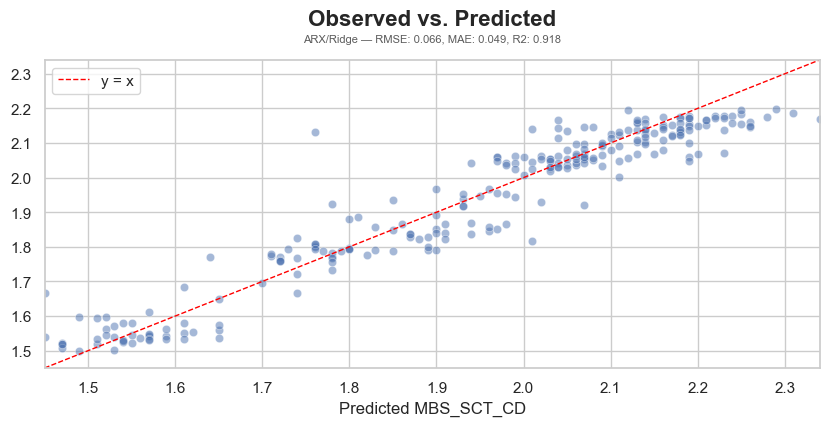

In [500]:
y_pred=SCT_CD_model.best_estimator_.predict(Xte[Xtr_.columns.to_list()])
y_test=yte

sns.set_style('whitegrid')
sns.set_context('notebook')
plt.figure(figsize = (10,4))
print(f"ARX/Ridge — RMSE: {rmse(y_test, y_pred):.3f}, MAE: {mean_absolute_error(y_test, y_pred):.3f}, R2: {r2_score(y_test, y_pred):.3f}")
ax=sns.scatterplot(x=y_test,y=y_pred,alpha=0.5)
ax.text(x=0.5, y=1.1, s='Observed vs. Predicted', fontsize=16, weight='bold', ha='center', va='bottom', transform=ax.transAxes)
ax.text(x=0.5, y=1.05, s=f"ARX/Ridge — RMSE: {rmse(y_test, y_pred):.3f}, MAE: {mean_absolute_error(y_test, y_pred):.3f}, R2: {r2_score(y_test, y_pred):.3f}", fontsize=8, alpha=0.75, ha='center', va='bottom', transform=ax.transAxes)
target_name=ycol
ax.set_xlabel("Observed "+target_name)
ax.set_xlabel("Predicted "+target_name)
lims = [
    np.nanmin([y_test.min(), y_pred.min()]),
    np.nanmax([y_test.max(), y_pred.max()])
]
ax.plot(lims, lims, linestyle="--", color="red", linewidth=1, label="y = x")
ax.set_xlim(lims)
ax.set_ylim(lims)
ax.legend()

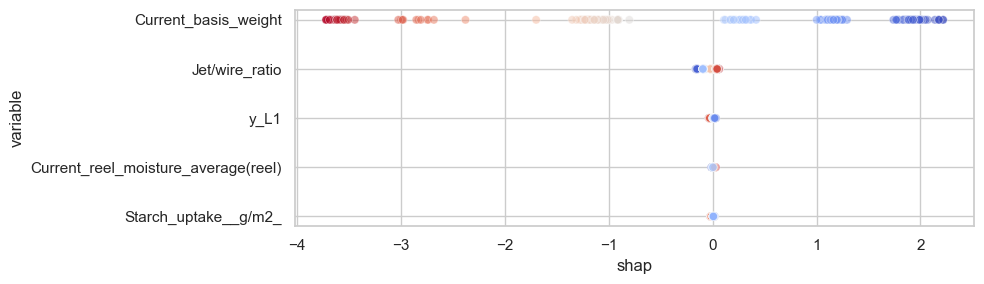

In [572]:
all_vars = Xtr_.columns.to_list()
pipe = SCT_CD_model.best_estimator_
if "selectK" in pipe.named_steps.keys():
    selector = pipe.named_steps["selectK"]
    sel_vars = [v for v, keep in zip(all_vars, selector.get_support()) if keep]
else:
    selector = None
    sel_vars = all_vars

ridge    = pipe.named_steps["ridge"]

#list_vars=Xte[exog_vars].columns.to_list()
model=pipe
xx=np.array(Xte[sel_vars])
Exx=np.tile(xx.mean(axis=0),xx.shape[0]).reshape((xx.shape[0],-1))

shap_df=pd.merge(pd.melt(pd.DataFrame(xx-Exx,columns=sel_vars)),pd.melt(pd.DataFrame(model["ridge"].coef_.reshape((-1,1)).T,columns=sel_vars),value_name="weight"),on="variable",how="left")
shap_df["shap"]=shap_df["value"]*shap_df["weight"]
shap_df["value"]=shap_df.groupby("variable").value.transform(lambda x: (x - x.min())/(x.max() - x.min()))
shap_df["rank"]=shap_df.groupby("variable").shap.transform(lambda x: (x.max() - x.min()))
shap_df=shap_df.sort_values("rank",ascending=False)

plt.figure(figsize = (10,3))
ax=sns.scatterplot(shap_df,y="variable",x="shap",hue="value",palette=plt.cm.get_cmap('coolwarm').reversed(),legend=False,alpha=0.5)
plt.tight_layout()

# Cost function

In [12]:
def costFibreStarch(df):
    return (146.46*(df["Current_basis_weight"]*(1-df["Current_reel_moisture_average(reel)"]/100)-df["Starch_uptake__g/m2_"])/(df["Current_basis_weight"]*1e6)+0.43422*df["Starch_uptake__g/m2_"]/1000).values
    

In [35]:
costFibreStarch(turnup[:2])

array([0.0022531 , 0.00225052])

# Joint distribution

In [634]:
joint_distribution = {}
for grammage in turnup.grammage.unique():
    joint_distribution[grammage] = GaussianCopulaContinuous(random_state=42).fit(turnup[turnup.grammage==grammage][control_vars])

In [82]:
turnup["AB_Grade_ID"].unique()

array([3200115, 3300100, 6010100, 6010085, 6010090, 3300110, 3300120,
       6010120])

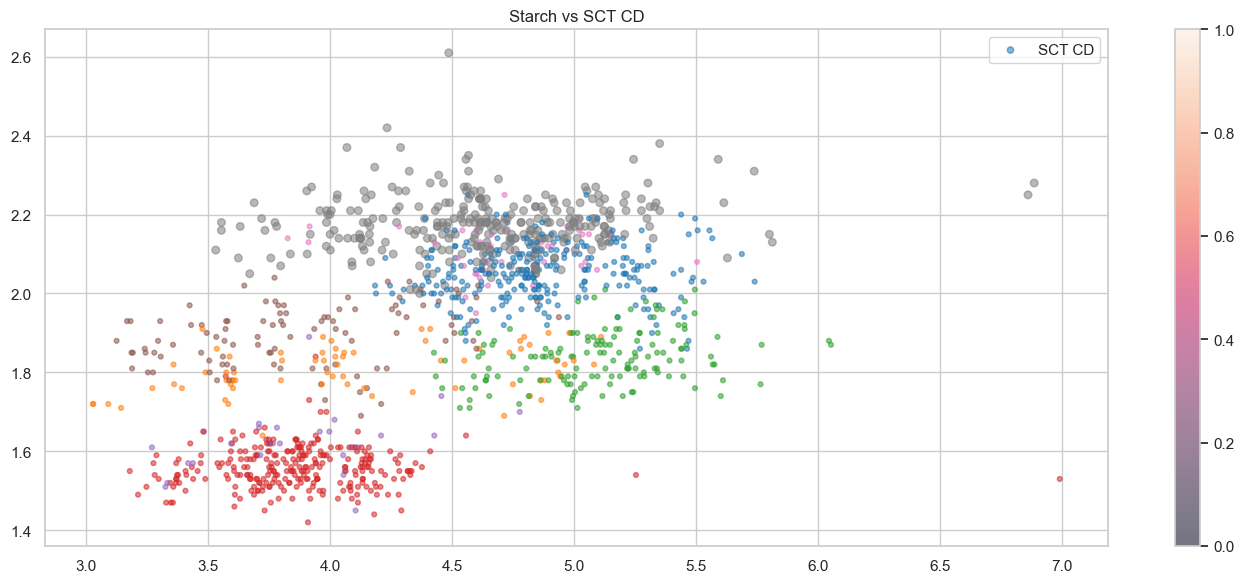

In [502]:
import matplotlib.cm as cm

xr, yr = turnup["Starch_uptake__g/m2_"].to_numpy(), turnup["MBS_SCT_CD"].to_numpy()
hue = turnup["AB_Grade_ID"]

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span



# plot (let matplotlib pick distinct colors)
colors = {3200115:'tab:blue', 3300100:'tab:orange', 6010100:'tab:green', 6010085:'tab:red', 6010090:'tab:purple', 3300110:'tab:brown', 3300120:'tab:pink', 6010120:'tab:gray'}
sizes = {3200115:12, 3300100:12, 6010100:12, 6010085:12, 6010090:12, 3300110:12, 3300120:12, 6010120:30}
plt.figure(figsize=(14, 6))
plt.scatter(xr, yr, c=hue.map(colors), s=hue.map(sizes), alpha=0.55, label="SCT CD")


plt.title(f"Starch vs SCT CD")
plt.legend()
plt.tight_layout()
plt.colorbar()
plt.show()

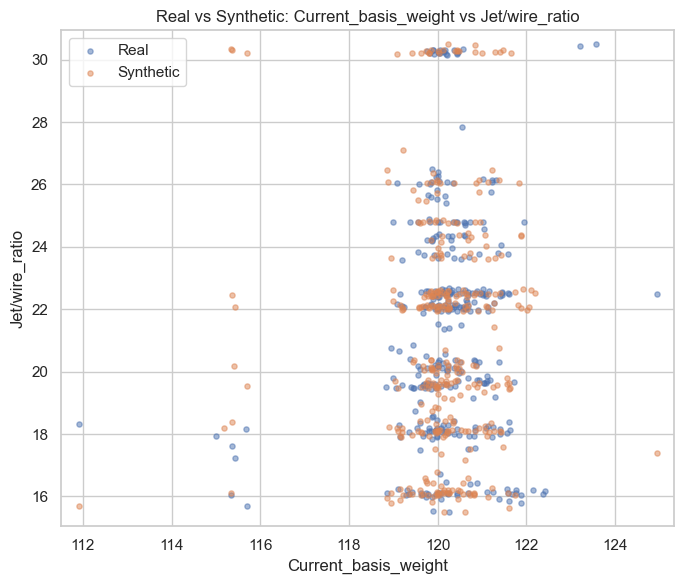

In [639]:
point_size=14
alpha = 0.5

grammage=120
df_real=turnup[turnup.grammage==grammage][control_vars]
n_synth = len(df_real)

x_col, y_col = tuple(np.random.choice(df_real.columns, size=2, replace=False))

# make synthetic sample
n_synth = n_synth or len(df_real)
df_synth = joint_distribution[grammage].sample(n_synth)

# extract the two columns
xr, yr = df_real[x_col].to_numpy(), df_real[y_col].to_numpy()
xs, ys = df_synth[x_col].to_numpy(), df_synth[y_col].to_numpy()

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span

xlim = _lims(xr, xs)
ylim = _lims(yr, ys)

# plot (let matplotlib pick distinct colors)
plt.figure(figsize=(7, 6))
plt.scatter(xr, yr, s=point_size, alpha=alpha, label="Real")
plt.scatter(xs, ys, s=point_size, alpha=alpha, label="Synthetic")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"Real vs Synthetic: {x_col} vs {y_col}")
plt.xlim(*xlim)
plt.ylim(*ylim)
plt.legend()
plt.tight_layout()
plt.show()

# Optimization

In [726]:
target_variable = "MBS_SCT_CD"
grammage = 120

df_fixed = pd.DataFrame([{"Current_basis_weight": 120.0, "Current_reel_moisture_average(reel)": 9.0, "MBS_SCT_CD": 2.2, "Starch_uptake__g/m2_":5, "Jet/wire_ratio":22}])

df_hist=turnup[turnup.grammage==120][df_fixed.columns]
df_hist.loc[(df_hist["Current_basis_weight"] < grammage-3), "Current_basis_weight"] = np.nan
df_hist.loc[(df_hist["Current_basis_weight"] > grammage+3), "Current_basis_weight"] = np.nan
joint = GaussianCopulaContinuous(random_state=42).fit(df_hist)

cond_summary = joint.conditional_summary(target_variable, df_fixed, n=100_000, quantiles=(0.05, 0.5, 0.95))
print(f"Conditional {target_variable} (from joint):", cond_summary)

Conditional MBS_SCT_CD (from joint): {'mean': 2.140413951370257, 'std': 0.07115097109275102, 'q05': 2.0260985383092827, 'q50': 2.1414196395249814, 'q95': 2.255096393174887}


In [727]:

control_variable = "Current_basis_weight"

result = data_aware_optimization(
    target_variable,
    2.05,
    control_variable,
    joint=joint_distribution[grammage],
    df_hist=df_hist,
    df_fixed=df_fixed,
    costFunction=costFibreStarch,
    strength_model=SCT_CD_model,
    lam_ll=1e-10,
    alpha_close=0,
    q_bounds=(0.01, 0.99),
    grid_step=0.01,
    safety_pad=0.10,
    pre_expand=0.10,   # expand grid by ±10%
    post_expand=0.30,  # pad final bounds by +10% of their width
    control_min=grammage-2,
    control_max=grammage+2,
    nonneg_control=True,
    method="COBYLA",
    strength_minimisation=True,
    verbose=True
)

print("\n=== Final recommendation ===")
print(f"Optimal {control_variable}:", result["control_opt"])
print("Strength:", result["strength"])
print("Cost:", result["cost"])
print("LogLik:", result["loglik"])
print("Bounds used:", result["bounds"])

Conditional control bounds (expanded): [118.363327, 122.000000]
Status: Return from COBYLA because the trust region radius reaches its lower bound. (success=True)
Start s: 120.000000  ->  Optimal s: 118.363327
Predicted Strength: 2.1300  (>= 2.05)
Cost: 0.002298
Objective: 0.002298

=== Final recommendation ===
Optimal Current_basis_weight: 118.36332685556164
Strength: 2.1299744905402056
Cost: 0.0022981917174625262
LogLik: -9.527110378831338
Bounds used: (np.float64(118.36332685556164), 122.0)


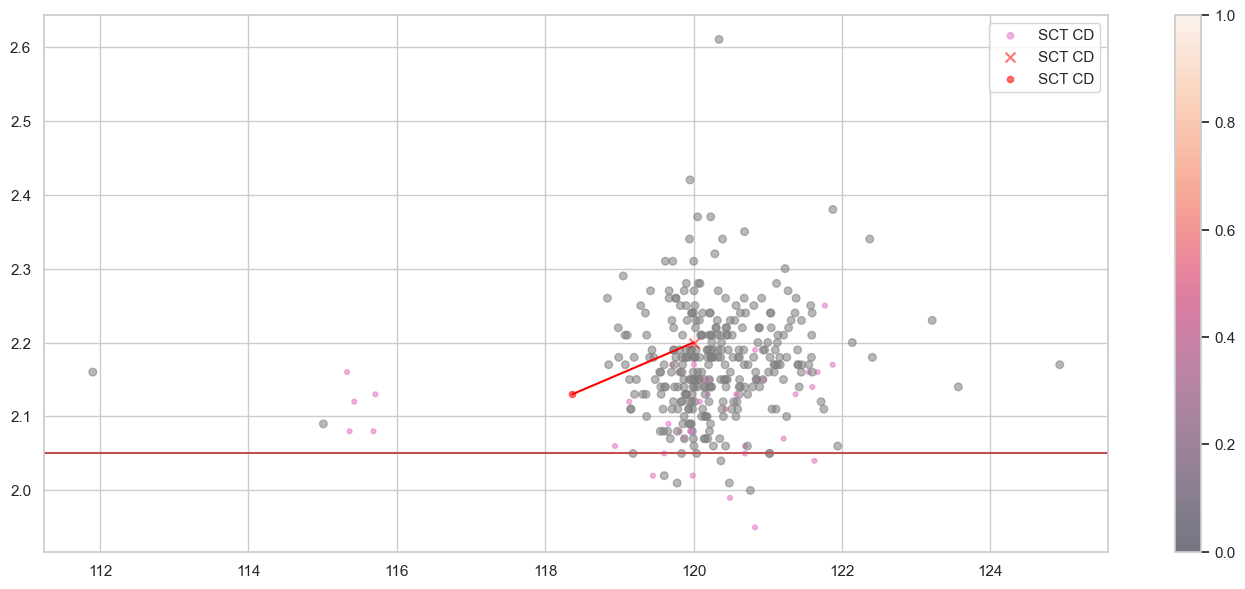

In [728]:
import matplotlib.cm as cm

control_range=np.arange(result["bounds"][0], result["bounds"][1], 0.01)

newdf=pd.DataFrame(np.repeat(df_fixed.values, repeats=len(control_range), axis=0), columns=df_fixed.columns)
newdf[control_variable]=control_range
if result["strength_model"]:
    required_cols = model_feature_names(SCT_CD_model, df_hist.columns)
    if 'y_L1' in required_cols and target_variable in df_fixed.columns:
        newdf=newdf.rename(columns={target_variable:'y_L1'})    
    newdf["MBS_SCT_pred"] = SCT_CD_model.predict(newdf[required_cols])
else:    
    newdf["MBS_SCT_pred"]=newdf.apply(lambda r: pd.Series(joint.conditional_summary("MBS_SCT_CD", r.to_frame().T, n=100_000, quantiles=(0.05, 0.5, 0.95))),axis=1)["mean"]

xr, yr = turnup[turnup.grammage==grammage][control_variable].to_numpy(), turnup[turnup.grammage==grammage]["MBS_SCT_CD"].to_numpy()
hue = turnup[turnup.grammage==grammage]["AB_Grade_ID"]

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span



# plot (let matplotlib pick distinct colors)
colors = {3200115:'tab:blue', 3300100:'tab:orange', 6010100:'tab:green', 6010085:'tab:red', 6010090:'tab:purple', 3300110:'tab:brown', 3300120:'tab:pink', 6010120:'tab:gray'}
sizes = {3200115:12, 3300100:12, 6010100:12, 6010085:12, 6010090:12, 3300110:12, 3300120:12, 6010120:30}
plt.figure(figsize=(14, 6))
plt.scatter(xr, yr, c=hue.map(colors), s=hue.map(sizes), alpha=0.55, label="SCT CD")
plt.scatter(result["control_init"], df_fixed[target_variable],c="red", s=50, alpha=0.55, label="SCT CD",marker="x")
plt.scatter(result["control_opt"], result["strength"],c="red", s=20, alpha=0.55, label="SCT CD",marker="o")
plt.plot(np.array([result["control_init"], result["control_opt"]]), np.array([df_fixed[target_variable].values[0], result["strength"]]),c="red")
plt.axhline(y=2.05, color='r', linestyle='-')
#plt.scatter(newdf[control_variable], newdf["MBS_SCT_pred"],c=pd.Series([6010120]).map(colors), s=1, alpha=0.55, label="SCT CD_pred")


plt.legend()
plt.tight_layout()
plt.colorbar()
plt.show()

In [729]:
df_fixed[control_variable] = result["control_opt"]
#df_fixed[target_variable] = result["strength"]

In [730]:
target_variable = "MBS_SCT_CD"

control_variable= "Starch_uptake__g/m2_"

result = data_aware_optimization(
    target_variable,
    2.05,
    control_variable,
    joint=joint_distribution[grammage],
    df_hist=df_hist,
    df_fixed=df_fixed,
    costFunction=costFibreStarch,
    strength_model=SCT_CD_model,
    lam_ll=1e-10,
    alpha_close=0,
    q_bounds=(0.01, 0.99),
    grid_step=0.01,
    safety_pad=0.10,
    pre_expand=0.10,   # expand grid by ±10%
    post_expand=0.10,  # pad final bounds by +10% of their width
    nonneg_control=True,
    method="COBYLA",
    strength_minimisation=True,
    verbose=True
)

print("\n=== Final recommendation ===")
print(f"Optimal {control_variable}:", result["control_opt"])
print("Strength:", result["strength"])
print("Cost:", result["cost"])
print("LogLik:", result["loglik"])
print("Bounds used:", result["bounds"])

df_fixed[control_variable] = result["control_opt"]


Conditional control bounds (expanded): [3.276860, 5.977194]
Status: Return from COBYLA because the trust region radius reaches its lower bound. (success=True)
Start s: 5.000000  ->  Optimal s: 3.276860
Predicted Strength: 2.0829  (>= 2.05)
Cost: 0.001552
Objective: 0.001552

=== Final recommendation ===
Optimal Starch_uptake__g/m2_: 3.27685979503472
Strength: 2.0828828585518946
Cost: 0.0015521019508712456
LogLik: -13.150807112106218
Bounds used: (3.27685979503472, 5.977193553472186)


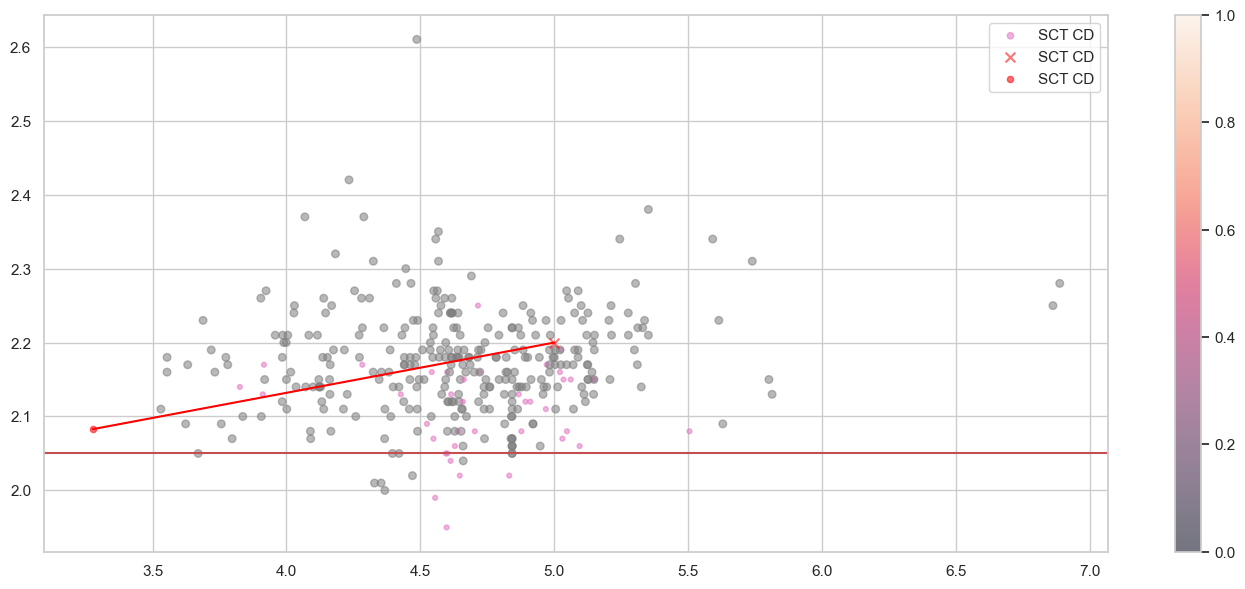

In [731]:
import matplotlib.cm as cm

control_range=np.arange(result["bounds"][0], result["bounds"][1], 0.01)

newdf=pd.DataFrame(np.repeat(df_fixed.values, repeats=len(control_range), axis=0), columns=df_fixed.columns)
newdf[control_variable]=control_range
if result["strength_model"]:
    required_cols = model_feature_names(SCT_CD_model, df_hist.columns)
    if 'y_L1' in required_cols and target_variable in df_fixed.columns:
        newdf=newdf.rename(columns={target_variable:'y_L1'})    
    newdf["MBS_SCT_pred"] = SCT_CD_model.predict(newdf[required_cols])
else:    
    newdf["MBS_SCT_pred"]=newdf.apply(lambda r: pd.Series(joint.conditional_summary("MBS_SCT_CD", r.to_frame().T, n=100_000, quantiles=(0.05, 0.5, 0.95))),axis=1)["mean"]

xr, yr = turnup[turnup.grammage==grammage][control_variable].to_numpy(), turnup[turnup.grammage==grammage]["MBS_SCT_CD"].to_numpy()
hue = turnup[turnup.grammage==grammage]["AB_Grade_ID"]

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span



# plot (let matplotlib pick distinct colors)
colors = {3200115:'tab:blue', 3300100:'tab:orange', 6010100:'tab:green', 6010085:'tab:red', 6010090:'tab:purple', 3300110:'tab:brown', 3300120:'tab:pink', 6010120:'tab:gray'}
sizes = {3200115:12, 3300100:12, 6010100:12, 6010085:12, 6010090:12, 3300110:12, 3300120:12, 6010120:30}
plt.figure(figsize=(14, 6))
plt.scatter(xr, yr, c=hue.map(colors), s=hue.map(sizes), alpha=0.55, label="SCT CD")
plt.scatter(result["control_init"], df_fixed[target_variable],c="red", s=50, alpha=0.55, label="SCT CD",marker="x")
plt.scatter(result["control_opt"], result["strength"],c="red", s=20, alpha=0.55, label="SCT CD",marker="o")
plt.plot(np.array([result["control_init"], result["control_opt"]]), np.array([df_fixed[target_variable].values[0], result["strength"]]),c="red")
plt.axhline(y=2.05, color='r', linestyle='-')
#plt.scatter(newdf[control_variable], newdf["MBS_SCT_pred"],c=pd.Series([6010120]).map(colors), s=1, alpha=0.55, label="SCT CD_pred")


plt.legend()
plt.tight_layout()
plt.colorbar()
plt.show()

In [732]:
df_fixed[control_variable] = result["control_opt"]
#df_fixed[target_variable] = result["strength"]

In [733]:
target_variable = "MBS_SCT_CD"

control_variable= "Jet/wire_ratio"

result = data_aware_optimization(
    target_variable,
    2.05,
    control_variable,
    joint=joint_distribution[grammage],
    df_hist=df_hist,
    df_fixed=df_fixed,
    costFunction=costFibreStarch,
    strength_model = SCT_CD_model,
    lam_ll=0,
    alpha_close=0,
    q_bounds=(0.01, 0.99),
    grid_step=0.01,
    safety_pad=0.0,
    pre_expand=0.0,   # expand grid by ±10%
    post_expand=0.0,  # pad final bounds by +10% of their width
    nonneg_control=True,
    method="COBYLA",
    strength_minimisation=False,
    verbose=True
)

print("\n=== Final recommendation ===")
print(f"Optimal {control_variable}:", result["control_opt"])
print("Strength:", result["strength"])
print("Cost:", result["cost"])
print("LogLik:", result["loglik"])
print("Bounds used:", result["bounds"])

df_fixed[control_variable] = result["control_opt"]

Conditional control bounds (expanded): [15.831940, 29.664595]
Status: Return from COBYLA because the trust region radius reaches its lower bound. (success=True)
Start s: 22.000000  ->  Optimal s: 15.831940
Predicted Strength: 2.0938  (>= 2.05)
Cost: 0.001552
Objective: -2.093791

=== Final recommendation ===
Optimal Jet/wire_ratio: 15.831940303237301
Strength: 2.0937908443791757
Cost: 0.0015521019508712456
LogLik: -11.04021017364159
Bounds used: (15.8319403032373, 29.664594898458756)


In [734]:
pd.concat(result["xx"],axis=0)

,Current_basis_weight,Current_reel_moisture_average(reel),Starch_uptake__g/m2_,Jet/wire_ratio,y_L1
0,118.363327,9.0,3.27686,22.000000,2.2
0,118.363327,9.0,3.27686,22.200000,2.2
0,118.363327,9.0,3.27686,21.800000,2.2
0,118.363327,9.0,3.27686,21.400000,2.2
0,118.363327,9.0,3.27686,20.600000,2.2
0,118.363327,9.0,3.27686,19.000000,2.2
0,118.363327,9.0,3.27686,15.831940,2.2
0,118.363327,9.0,3.27686,15.731940,2.2
0,118.363327,9.0,3.27686,15.831233,2.2
0,118.363327,9.0,3.27686,15.831940,2.2


<Axes: xlabel='Jet/wire_ratio'>

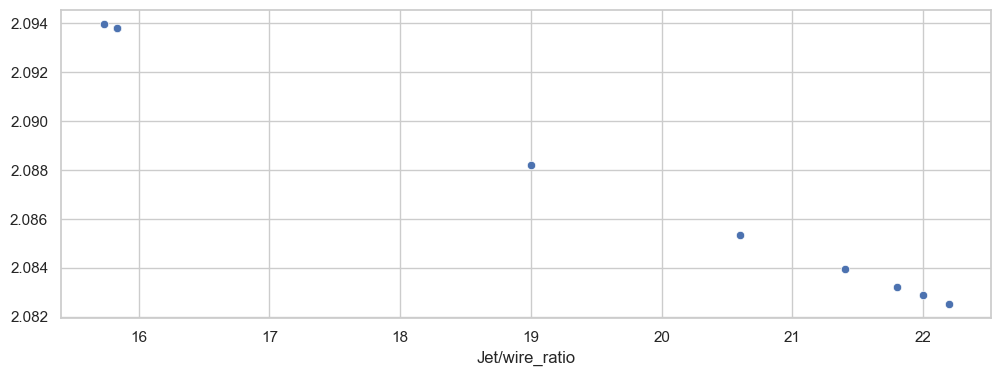

In [735]:
sns.scatterplot(x=pd.concat(result["xx"],axis=0)[control_variable], y=result["yy"])

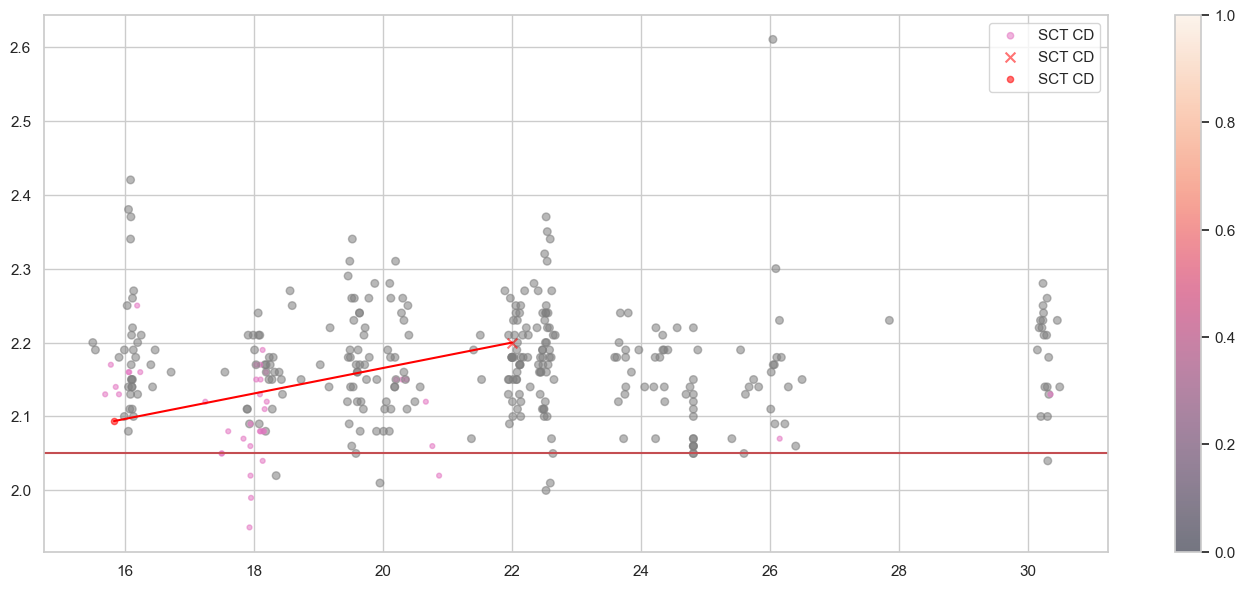

In [736]:
import matplotlib.cm as cm

control_range=np.arange(result["bounds"][0], result["bounds"][1], 0.01)

newdf=pd.DataFrame(np.repeat(df_fixed.values, repeats=len(control_range), axis=0), columns=df_fixed.columns)
newdf[control_variable]=control_range
if result["strength_model"]:
    required_cols = model_feature_names(SCT_CD_model, df_hist.columns)
    if 'y_L1' in required_cols and target_variable in df_fixed.columns:
        newdf=newdf.rename(columns={target_variable:'y_L1'})    
    newdf["MBS_SCT_pred"] = SCT_CD_model.predict(newdf[required_cols])
else:    
    newdf["MBS_SCT_pred"]=newdf.apply(lambda r: pd.Series(joint.conditional_summary("MBS_SCT_CD", r.to_frame().T, n=100_000, quantiles=(0.05, 0.5, 0.95))),axis=1)["mean"]

xr, yr = turnup[turnup.grammage==grammage][control_variable].to_numpy(), turnup[turnup.grammage==grammage]["MBS_SCT_CD"].to_numpy()
hue = turnup[turnup.grammage==grammage]["AB_Grade_ID"]

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span



# plot (let matplotlib pick distinct colors)
colors = {3200115:'tab:blue', 3300100:'tab:orange', 6010100:'tab:green', 6010085:'tab:red', 6010090:'tab:purple', 3300110:'tab:brown', 3300120:'tab:pink', 6010120:'tab:gray'}
sizes = {3200115:12, 3300100:12, 6010100:12, 6010085:12, 6010090:12, 3300110:12, 3300120:12, 6010120:30}
plt.figure(figsize=(14, 6))
plt.scatter(xr, yr, c=hue.map(colors), s=hue.map(sizes), alpha=0.55, label="SCT CD")
plt.scatter(result["control_init"], df_fixed[target_variable],c="red", s=50, alpha=0.55, label="SCT CD",marker="x")
plt.scatter(result["control_opt"], result["strength"],c="red", s=20, alpha=0.55, label="SCT CD",marker="o")
plt.plot(np.array([result["control_init"], result["control_opt"]]), np.array([df_fixed[target_variable].values[0], result["strength"]]),c="red")
plt.axhline(y=2.05, color='r', linestyle='-')
#plt.scatter(newdf[control_variable], newdf["MBS_SCT_pred"],c=pd.Series([6010120]).map(colors), s=1, alpha=0.55, label="SCT CD_pred")


plt.legend()
plt.tight_layout()
plt.colorbar()
plt.show()

In [661]:
q_bounds=(0.01, 0.99)
grid_step= 0.01
safety_pad = 0.00
control_min = None
control_max = None
nonneg_control = True
pre_expand = 0.0                       # expand the grid range before quantiles
post_expand = 0.0                       # expand final [lo,hi] after quantiles
free_variable="Jet/wire_ratio"
#free_variable="Current_basis_weight"

if isinstance(df_fixed, dict):
        df_fixed = pd.DataFrame([df_fixed])
df_fixed = df_fixed.iloc[[0]]

# numeric history (for empirical envelope)
df_num = df_hist.copy().apply(pd.to_numeric, errors="coerce")
df_num = df_num.fillna(df_num.median(numeric_only=True))

# wide empirical envelope for starch
s_hist = pd.to_numeric(df_hist[free_variable], errors="coerce").dropna().to_numpy()

if s_hist.size:
    q_lo_emp, q_hi_emp = np.quantile(s_hist, [0.01, 0.99])
else:
    q_lo_emp, q_hi_emp = (0.0, 1.0)
print(q_lo_emp,q_hi_emp)

span = max(q_hi_emp - q_lo_emp, 1.0)
lo_emp = q_lo_emp - safety_pad * span
hi_emp = q_hi_emp + safety_pad * span
if nonneg_control: lo_emp = max(0.0, lo_emp)
if control_min is not None: lo_emp = max(lo_emp, float(control_min))
if control_max is not None: hi_emp = min(hi_emp, float(control_max))
if hi_emp <= lo_emp:
    hi_emp = lo_emp + max(1.0, grid_step)
print(lo_emp,hi_emp)

cols = joint_distribution[grammage].columns_
tpl = df_num.median(numeric_only=True).reindex(cols, fill_value=0.0).astype(float)
for c in df_fixed.columns.intersection(cols):
    v = pd.to_numeric(df_fixed.iloc[0][c], errors="coerce")
    if pd.notna(v): tpl[c] = float(v)

# Pre-expand the grid window 
base_span = hi_emp - lo_emp
lo_grid = lo_emp - pre_expand * base_span
hi_grid = hi_emp + pre_expand * base_span
if nonneg_control: lo_grid = max(0.0, lo_grid)
if control_min is not None: lo_grid = max(lo_grid, float(control_min))
if control_max is not None: hi_grid = min(hi_grid, float(control_max))
if hi_grid <= lo_grid: hi_grid = lo_grid + max(1.0, grid_step)    

grid = np.arange(lo_emp, hi_emp + 1e-12, grid_step, dtype=float)
rows = []
for s in grid:
    r = tpl.copy(); r[free_variable] = float(s)
    rows.append(r)
slice_df = pd.DataFrame(rows, columns=cols)

# logpdf from joint (all columns)
logpdf = np.asarray(joint_distribution[grammage].score_samples(slice_df), dtype=float)
# stabilize & normalize to conditional pdf over starch
logpdf_stab = logpdf - np.max(logpdf)
unnorm = np.exp(logpdf_stab)
if not np.isfinite(unnorm).any() or unnorm.sum() == 0:
    unnorm = np.ones_like(unnorm)
Z = np.trapz(unnorm, grid)
pdf = unnorm / max(Z, np.finfo(float).tiny)
cdf = np.cumsum((pdf[:-1] + pdf[1:]) / 2 * np.diff(grid))
cdf = np.concatenate([[0.0], cdf]); cdf = np.clip(cdf, 0.0, 1.0)

q_lo, q_hi = q_bounds
lo = float(np.interp(q_lo, cdf, grid))
hi = float(np.interp(q_hi, cdf, grid))

15.815991933781742 30.3177333406383
15.815991933781742 30.3177333406383


<Axes: >

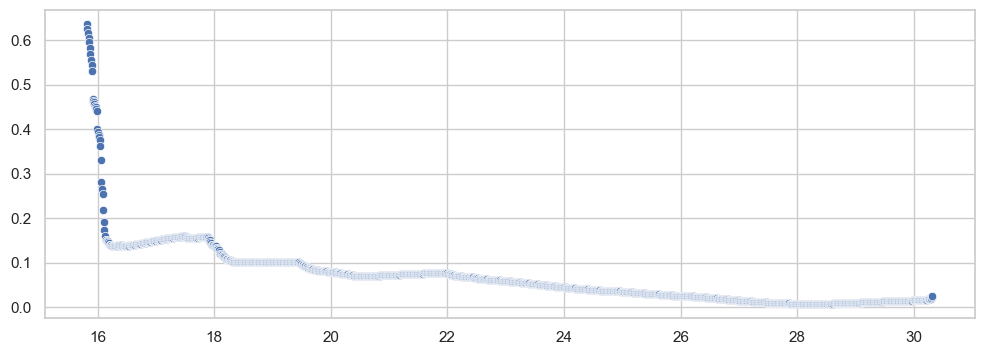

In [662]:
sns.scatterplot(x=grid, y=pdf)

# Sequential Optimisation

In [756]:
def squential_optimization(target_variable, target_value, control_variable, df_hist, df_fixed, joint_distribution, strength_model, cost_function, grammage, strength_minimisation = True):
    result = data_aware_optimization(
        target_variable,
        target_value,
        control_variable,
        joint=joint_distribution,
        df_hist=df_hist,
        df_fixed=df_fixed,
        costFunction=cost_function,
        strength_model = strength_model,
        lam_ll=0,
        alpha_close=0,
        q_bounds=(0.01, 0.99),
        grid_step=0.01,
        safety_pad=0.0,
        pre_expand=0.0,   
        post_expand=0.0,
        control_min= grammage - 2 if  control_variable=="Current_basis_weight" else None,
        control_max= grammage + 2 if  control_variable=="Current_basis_weight" else None,
        nonneg_control=True,
        method="COBYLA",
        strength_minimisation=strength_minimisation ,
        verbose=True
    )

    print("\n=== Final recommendation ===")
    print(f"Optimal {control_variable}:", result["control_opt"])
    print("Strength:", result["strength"])
    print("Cost:", result["cost"])
    print("LogLik:", result["loglik"])
    print("Bounds used:", result["bounds"])

    df_fixed[control_variable] = result["control_opt"]

    control_range=np.arange(result["bounds"][0], result["bounds"][1], 0.01)

    newdf=pd.DataFrame(np.repeat(df_fixed.values, repeats=len(control_range), axis=0), columns=df_fixed.columns)
    newdf[control_variable]=control_range
    if result["strength_model"]:
        required_cols = model_feature_names(SCT_CD_model, df_hist.columns)
        if 'y_L1' in required_cols and target_variable in df_fixed.columns:
            newdf=newdf.rename(columns={target_variable:'y_L1'})    
        newdf[target_variable+"_pred"] = SCT_CD_model.predict(newdf[required_cols])
    else:    
        newdf[target_variable+"_pred"]=newdf.apply(lambda r: pd.Series(joint.conditional_summary("MBS_SCT_CD", r.to_frame().T, n=100_000, quantiles=(0.05, 0.5, 0.95))),axis=1)["mean"]

    xr, yr = turnup[turnup.grammage==grammage][control_variable].to_numpy(), turnup[turnup.grammage==grammage]["MBS_SCT_CD"].to_numpy()
    hue = turnup[turnup.grammage==grammage]["AB_Grade_ID"]

    # compute common limits with a small margin
    def _lims(a, b, pad=0.03):
        lo = np.nanmin([a.min(), b.min()])
        hi = np.nanmax([a.max(), b.max()])
        span = hi - lo
        if span == 0:
            span = 1.0
        return lo - pad*span, hi + pad*span



    # plot (let matplotlib pick distinct colors)
    colors = {3200115:'tab:blue', 3300100:'tab:orange', 6010100:'tab:green', 6010085:'tab:red', 6010090:'tab:purple', 3300110:'tab:brown', 3300120:'tab:pink', 6010120:'tab:gray'}
    sizes = {3200115:12, 3300100:12, 6010100:12, 6010085:12, 6010090:12, 3300110:12, 3300120:12, 6010120:30}
    plt.figure(figsize=(14, 6))
    plt.scatter(xr, yr, c=hue.map(colors), s=hue.map(sizes), alpha=0.55, label="SCT CD")
    plt.scatter(result["control_init"], df_fixed[target_variable],c="red", s=50, alpha=0.55, label="SCT CD",marker="x")
    plt.scatter(result["control_opt"], result["strength"],c="red", s=20, alpha=0.55, label="SCT CD",marker="o")
    plt.plot(np.array([result["control_init"], result["control_opt"]]), np.array([df_fixed[target_variable].values[0], result["strength"]]),c="red")
    plt.axhline(y=2.05, color='r', linestyle='-')
    #plt.scatter(newdf[control_variable], newdf["MBS_SCT_pred"],c=pd.Series([6010120]).map(colors), s=1, alpha=0.55, label="SCT CD_pred")


    plt.legend()
    plt.tight_layout()
    plt.colorbar()
    plt.show()
    df_fixed[control_variable] = result["control_opt"]
    return df_fixed.copy(), result

In [772]:
target_variable = "MBS_SCT_CD"
target_value = 2.05
grammage = 120

df_fixed = pd.DataFrame([{"Current_basis_weight": 120.0, "Current_reel_moisture_average(reel)": 9.0, "MBS_SCT_CD": 2.2, "Starch_uptake__g/m2_":5, "Jet/wire_ratio":22}])

df_hist=turnup[turnup.grammage==120][df_fixed.columns]
df_hist.loc[(df_hist["Current_basis_weight"] < grammage-3), "Current_basis_weight"] = np.nan
df_hist.loc[(df_hist["Current_basis_weight"] > grammage+3), "Current_basis_weight"] = np.nan

status = []
status.append(df_fixed["MBS_SCT_CD"].values[0])

Conditional control bounds (expanded): [119.022026, 121.747046]
Status: Return from COBYLA because the trust region radius reaches its lower bound. (success=True)
Start s: 120.000000  ->  Optimal s: 119.022026
Predicted Strength: 2.1375  (>= 2.05)
Cost: 0.002298
Objective: 0.002298

=== Final recommendation ===
Optimal Current_basis_weight: 119.02202563464506
Strength: 2.137486165834154
Cost: 0.002298225957276141
LogLik: -7.211773494939015
Bounds used: (119.02202563464506, 121.74704644265888)


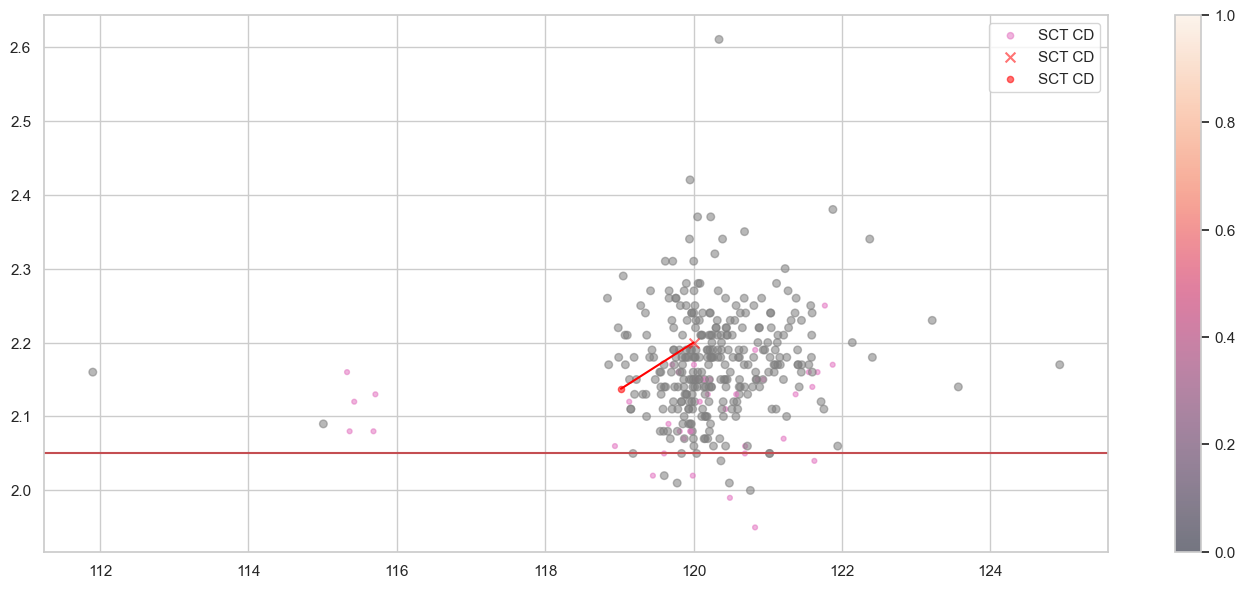

In [773]:
df_fixed, result = squential_optimization(target_variable, target_value, "Current_basis_weight", df_hist, df_fixed, joint_distribution[grammage], SCT_CD_model, costFibreStarch, grammage, strength_minimisation = True)
status.append(result["strength"])

Conditional control bounds (expanded): [3.676254, 5.629338]
Status: Return from COBYLA because the trust region radius reaches its lower bound. (success=True)
Start s: 5.000000  ->  Optimal s: 3.676254
Predicted Strength: 2.1013  (>= 2.05)
Cost: 0.001725
Objective: 0.001725

=== Final recommendation ===
Optimal Starch_uptake__g/m2_: 3.676254031750352
Strength: 2.1013095634873475
Cost: 0.0017250578901427363
LogLik: -8.36087431878958
Bounds used: (3.6762540317503514, 5.629337611822775)


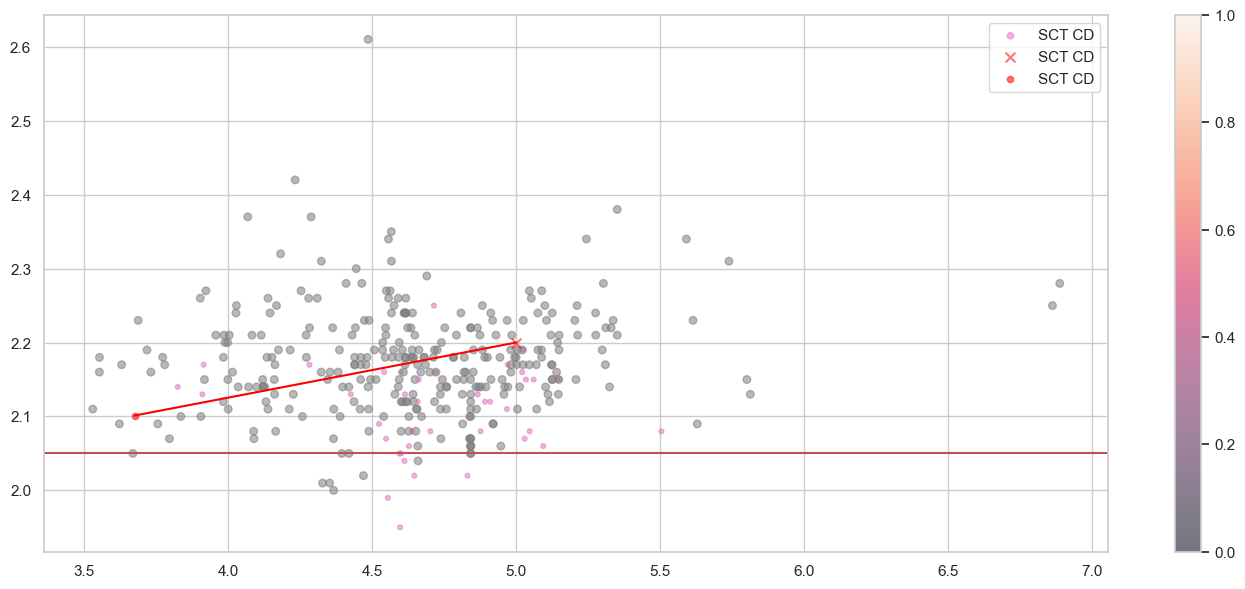

In [774]:
df_fixed, result = squential_optimization(target_variable, target_value, "Starch_uptake__g/m2_", df_hist, df_fixed, joint_distribution[grammage], SCT_CD_model, costFibreStarch, grammage, strength_minimisation = True)
status.append(result["strength"])

Conditional control bounds (expanded): [15.839549, 29.536278]
Status: Return from COBYLA because the trust region radius reaches its lower bound. (success=True)
Start s: 22.000000  ->  Optimal s: 15.839549
Predicted Strength: 2.1122  (>= 2.05)
Cost: 0.001725
Objective: -2.112204

=== Final recommendation ===
Optimal Jet/wire_ratio: 15.839549282775012
Strength: 2.112204093115267
Cost: 0.0017250578901427363
LogLik: -6.734555838426989
Bounds used: (15.83954928277501, 29.536277606189287)


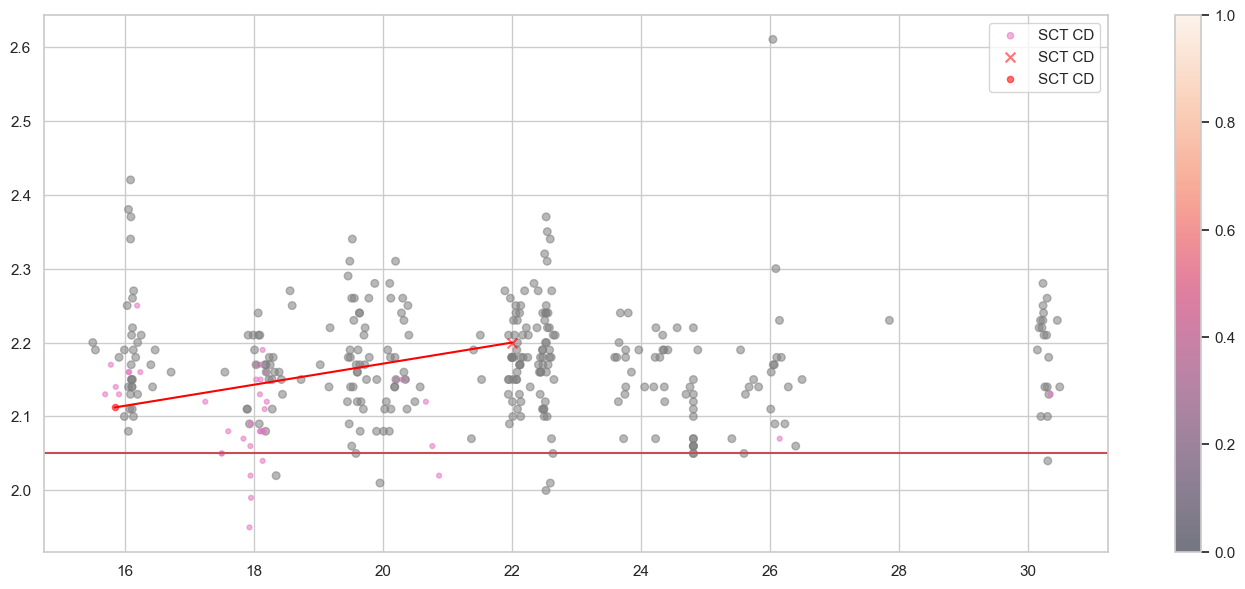

In [775]:
df_fixed, result = squential_optimization(target_variable, target_value, "Jet/wire_ratio", df_hist, df_fixed, joint_distribution[grammage], SCT_CD_model, costFibreStarch, grammage, strength_minimisation = False)
status.append(result["strength"])

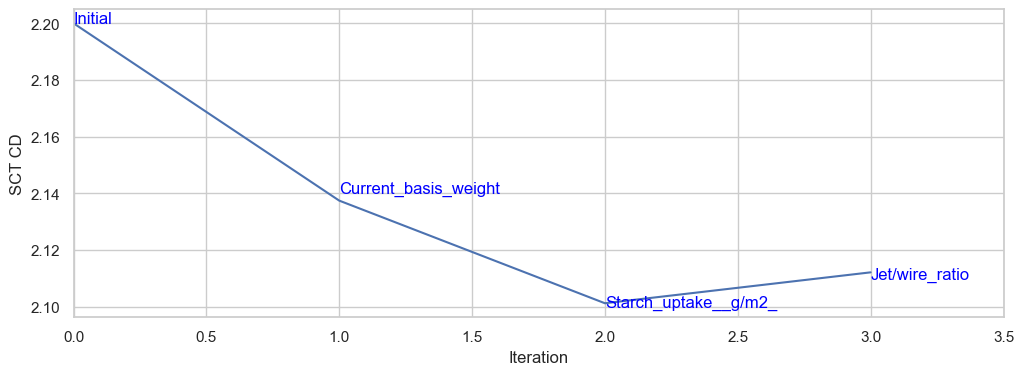

In [787]:
ax=sns.lineplot(y=status, x=range(0,len(status)))
ax.set(xlabel='Iteration', ylabel='SCT CD')
ax.set_xlim(0,3.5)
_=plt.text(x=0, y=2.20, s="Initial", fontsize=12, color='blue')
_=plt.text(x=1, y=2.14, s="Current_basis_weight", fontsize=12, color='blue')
_=plt.text(x=2, y=2.10, s="Starch_uptake__g/m2_", fontsize=12, color='blue')
_=plt.text(x=3, y=2.11, s="Jet/wire_ratio", fontsize=12, color='blue')

# CMT300

In [58]:
import numpy as np
import pandas as pd
from scipy.stats import norm
from sklearn.covariance import LedoitWolf

class GaussianCopulaContinuous:
    def __init__(self, bandwidth: float | None = None, random_state: int | None = None, eps: float = 1e-6):
        self.bandwidth = bandwidth
        self.random_state = random_state
        self.eps = eps
        self.columns_ = None
        self.marginals_ = None
        self.R_ = None
        self.R_inv_ = None
        self.logdet_R_ = None
        self._rng = np.random.default_rng(random_state)

    def fit(self, X: pd.DataFrame):
        if not np.all([pd.api.types.is_numeric_dtype(X[c]) for c in X.columns]):
            raise ValueError("All columns must be numeric.")
        df = X.copy()
        self.columns_ = list(df.columns)
        for c in self.columns_:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())
        # NOTE: ContinuousMarginal must exist in your environment
        self.marginals_ = {c: ContinuousMarginal(self.bandwidth, self.eps).fit(df[c].to_numpy())
                           for c in self.columns_}
        U = np.column_stack([self.marginals_[c].cdf(df[c].to_numpy()) for c in self.columns_])
        Z = norm.ppf(np.clip(U, self.eps, 1 - self.eps))
        lw = LedoitWolf().fit(Z)
        Sigma = lw.covariance_
        d = np.sqrt(np.diag(Sigma)); d[d == 0] = 1.0
        R = Sigma / np.outer(d, d)
        R = (R + R.T) / 2.0
        self.R_ = R
        self.R_inv_ = np.linalg.inv(R)
        sign, logdet = np.linalg.slogdet(R)
        if sign <= 0:
            raise RuntimeError("Estimated correlation not PD.")
        self.logdet_R_ = logdet
        return self

    def _check(self):
        if self.R_ is None or self.marginals_ is None or self.columns_ is None:
            raise RuntimeError("Model not fitted.")

    def _to_Z(self, X: pd.DataFrame) -> np.ndarray:
        df = X[self.columns_].copy()
        for c in self.columns_:
            df[c] = pd.to_numeric(df[c], errors="coerce").fillna(df[c].median())
        U = np.column_stack([self.marginals_[c].cdf(df[c].to_numpy()) for c in self.columns_])
        return norm.ppf(np.clip(U, self.eps, 1 - self.eps))

    def _log_copula_density(self, Z: np.ndarray) -> np.ndarray:
        q1 = np.einsum("...i,ij,...j->...", Z, self.R_inv_, Z)
        q0 = np.einsum("...i,...i->...", Z, Z)
        return -0.5 * self.logdet_R_ - 0.5 * (q1 - q0)

    def score_samples(self, X: pd.DataFrame) -> np.ndarray:
        self._check()
        Z = self._to_Z(X)
        log_m = 0.0
        for c in self.columns_:
            log_m += self.marginals_[c].log_pdf(np.asarray(X[c], dtype=float))
        return self._log_copula_density(Z) + log_m

    def sample(self, n: int) -> pd.DataFrame:
        self._check()
        L = np.linalg.cholesky(self.R_)
        Z = self._rng.standard_normal(size=(n, len(self.columns_))) @ L.T
        U = norm.cdf(Z)
        data = {c: self.marginals_[c].inv_cdf(U[:, j]) for j, c in enumerate(self.columns_)}
        return pd.DataFrame(data, columns=self.columns_)

    # ---- conditional utilities (single target; now backed by multi) ----
    def conditional_params(self, target: str, given_df: pd.DataFrame | dict) -> tuple[float, float]:
        mu_vec, Sigma = self.conditional_params_multi([target], given_df)
        return float(mu_vec[0]), float(max(Sigma[0, 0], 1e-9))

    def conditional_sample(self, target: str, given_df: pd.DataFrame | dict, n: int = 50_000) -> np.ndarray:
        df = self.conditional_sample_multi([target], given_df, n=n)
        return df[target].to_numpy()

    def conditional_summary(self, target: str, given_df: pd.DataFrame | dict, n: int = 100_000,
                            quantiles=(0.05, 0.5, 0.95)) -> dict:
        xs = self.conditional_sample(target, given_df, n=n)
        out = {"mean": float(np.mean(xs)), "std": float(np.std(xs, ddof=1))}
        for q in quantiles:
            out[f"q{int(q*100):02d}"] = float(np.quantile(xs, q))
        return out

    # ---- NEW: multivariate conditional utilities ----
    def conditional_params_multi(self, targets: list[str], given_df: pd.DataFrame | dict
                                 ) -> tuple[np.ndarray, np.ndarray]:
        """
        Compute N(mu, Sigma) of Z_targets | Z_given = z_g in copula space.
        """
        self._check()
        if isinstance(given_df, dict):
            given_df = pd.DataFrame([given_df])
        if len(given_df) != 1:
            raise ValueError("given_df must be single-row.")

        cols = self.columns_
        col_index = {c: i for i, c in enumerate(cols)}

        # Validate targets
        missing_t = [t for t in targets if t not in col_index]
        if missing_t:
            raise KeyError(f"Targets not in columns: {missing_t}")

        t_idx = [col_index[t] for t in targets]

        # Which given columns are present and not in targets?
        given_cols = [c for c in cols if (c in given_df.columns) and (c not in targets)]
        g_idx = [col_index[c] for c in given_cols]

        R = self.R_

        if len(g_idx) == 0:
            # Unconditional over targets
            R_tt = R[np.ix_(t_idx, t_idx)]
            mu = np.zeros(len(t_idx), dtype=float)
            Sigma = (R_tt + R_tt.T) / 2.0
            diag = np.clip(np.diag(Sigma), 1e-9, None)
            np.fill_diagonal(Sigma, diag)
            return mu, Sigma

        # Build one-row template with 'given' values (others ignored)
        tpl = pd.Series({c: given_df.iloc[0][c] if c in given_cols else 0.0 for c in cols}, dtype=float)
        Z_all = self._to_Z(pd.DataFrame([tpl], columns=cols))
        z_g = Z_all[0, g_idx]

        # Blocks
        R_tt = R[np.ix_(t_idx, t_idx)]
        R_tg = R[np.ix_(t_idx, g_idx)]
        R_gt = R[np.ix_(g_idx, t_idx)]
        R_gg = R[np.ix_(g_idx, g_idx)]

        # Conditional Gaussian
        R_gg_inv = np.linalg.inv(R_gg)
        mu = R_tg @ R_gg_inv @ z_g
        Sigma = R_tt - R_tg @ R_gg_inv @ R_gt

        # Numerical hygiene
        Sigma = (Sigma + Sigma.T) / 2.0
        diag = np.clip(np.diag(Sigma), 1e-9, None)
        np.fill_diagonal(Sigma, diag)
        return mu.astype(float), Sigma.astype(float)

    def conditional_sample_multi(self, targets: list[str], given_df: pd.DataFrame | dict, n: int = 50_000
                                 ) -> pd.DataFrame:
        """
        Jointly sample multiple target columns, conditional on 'given_df'.
        """
        mu, Sigma = self.conditional_params_multi(targets, given_df)

        k = len(targets)
        # Try Cholesky; add jitter if near-singular; fallback to eigen sqrt
        try:
            L = np.linalg.cholesky(Sigma)
        except np.linalg.LinAlgError:
            jitter = 1e-8
            for _ in range(6):
                try:
                    L = np.linalg.cholesky(Sigma + jitter * np.eye(k))
                    break
                except np.linalg.LinAlgError:
                    jitter *= 10
            else:
                w, V = np.linalg.eigh((Sigma + Sigma.T) / 2.0)
                w = np.clip(w, 1e-12, None)
                L = V @ np.diag(np.sqrt(w))

        Z = self._rng.standard_normal(size=(n, k)) @ L.T + mu  # (n,k)
        U = norm.cdf(Z)

        out = {}
        for j, c in enumerate(targets):
            out[c] = self.marginals_[c].inv_cdf(U[:, j])

        return pd.DataFrame(out, columns=targets)

    def conditional_summary_multi(self, targets: list[str], given_df: pd.DataFrame | dict, n: int = 100_000,
                                  quantiles=(0.05, 0.5, 0.95)) -> dict[str, dict]:
        """
        Per-target summaries of the conditional distribution.
        """
        samples = self.conditional_sample_multi(targets, given_df, n=n)
        summaries = {}
        for c in targets:
            xs = samples[c].to_numpy()
            stats = {"mean": float(np.mean(xs)), "std": float(np.std(xs, ddof=1))}
            for q in quantiles:
                stats[f"q{int(q*100):02d}"] = float(np.quantile(xs, q))
            summaries[c] = stats
        return summaries


In [81]:
control_vars_=[
    'Fibre__g/m2_',
    #'Current_basis_weight',
    'Current_reel_moisture_average(reel)',
    'Starch_uptake__g/m2_',
    'Jet/wire_ratio',
    #'Speed',
    "Rod_Pressure_Bottom_Roll",
    "Rod_pressure_Top_Roll",]

In [83]:
turnup_ = turnup[(turnup.grammage==grammage) & (turnup.AB_Grade_ID==6010120)]
turnup_ = turnup_[turnup_.MBS_CMT30>170]

joint_distribution_CMT_120 = GaussianCopulaContinuous(random_state=42).fit(turnup_[control_vars_+["MBS_CMT30"]])

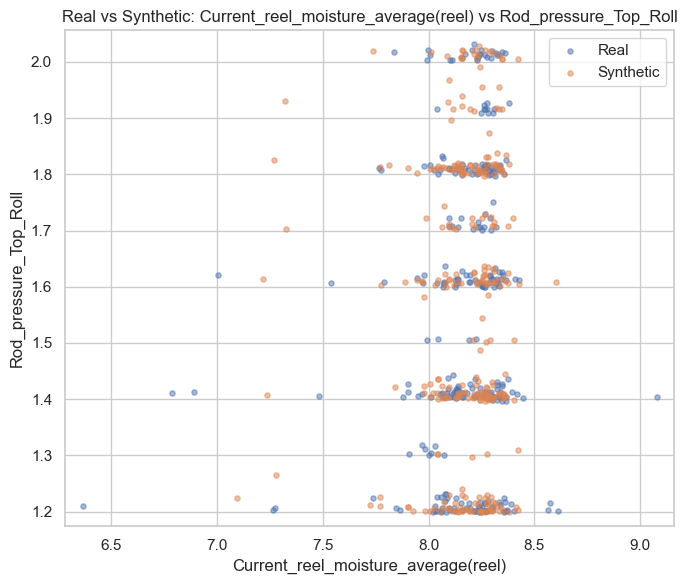

In [91]:
point_size=14
alpha = 0.5

grammage=120
df_real=turnup[(turnup.grammage==grammage) & (turnup.AB_Grade_ID==6010120)][control_vars_]
n_synth = len(df_real)

x_col, y_col = tuple(np.random.choice(df_real.columns, size=2, replace=False))

# make synthetic sample
n_synth = n_synth or len(df_real)
df_synth = joint_distribution_CMT_120.sample(n_synth)

# extract the two columns
xr, yr = df_real[x_col].to_numpy(), df_real[y_col].to_numpy()
xs, ys = df_synth[x_col].to_numpy(), df_synth[y_col].to_numpy()

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span

xlim = _lims(xr, xs)
ylim = _lims(yr, ys)

# plot (let matplotlib pick distinct colors)
plt.figure(figsize=(7, 6))
plt.scatter(xr, yr, s=point_size, alpha=alpha, label="Real")
plt.scatter(xs, ys, s=point_size, alpha=alpha, label="Synthetic")
plt.xlabel(x_col)
plt.ylabel(y_col)
plt.title(f"Real vs Synthetic: {x_col} vs {y_col}")
plt.xlim(*xlim)
plt.ylim(*ylim)
plt.legend()
plt.tight_layout()
plt.show()

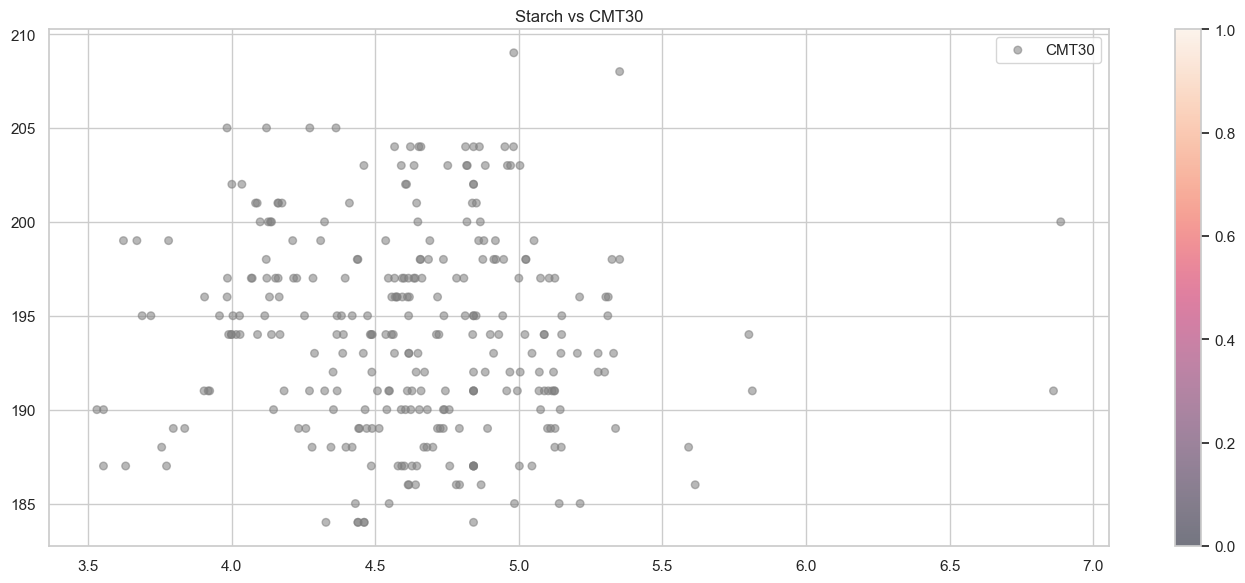

In [76]:
import matplotlib.cm as cm

turnup_ = turnup[(turnup.grammage==grammage) & (turnup.AB_Grade_ID==6010120)]
turnup_ = turnup_[turnup_.MBS_CMT30>170]
xr, yr = turnup_["Starch_uptake__g/m2_"].to_numpy(), turnup_["MBS_CMT30"].to_numpy()
hue = turnup_["AB_Grade_ID"]

# compute common limits with a small margin
def _lims(a, b, pad=0.03):
    lo = np.nanmin([a.min(), b.min()])
    hi = np.nanmax([a.max(), b.max()])
    span = hi - lo
    if span == 0:
        span = 1.0
    return lo - pad*span, hi + pad*span



# plot (let matplotlib pick distinct colors)
colors = {3200115:'tab:blue', 3300100:'tab:orange', 6010100:'tab:green', 6010085:'tab:red', 6010090:'tab:purple', 3300110:'tab:brown', 3300120:'tab:pink', 6010120:'tab:gray'}
sizes = {3200115:12, 3300100:12, 6010100:12, 6010085:12, 6010090:12, 3300110:12, 3300120:12, 6010120:30}
plt.figure(figsize=(14, 6))
plt.scatter(xr, yr, c=hue.map(colors), s=hue.map(sizes), alpha=0.55, label="CMT30")


plt.title(f"Starch vs CMT30")
plt.legend()
plt.tight_layout()
plt.colorbar()
plt.show()

In [93]:
target_variable = "MBS_CMT30"
control_variable="Starch_uptake__g/m2_"
target_value = 185
grammage = 120
control_range=np.arange(3.5, 6, 0.01)
#df_fixed = pd.DataFrame([{"Current_basis_weight": 120.0, "Current_reel_moisture_average(reel)": 9.0, "MBS_CMT30": 205, "Starch_uptake__g/m2_":5, "Jet/wire_ratio":22, "Speed":1250}])
df_fixed = pd.DataFrame([{'Fibre__g/m2_': 105.0, "Current_reel_moisture_average(reel)": 9.0, "MBS_CMT30": 205, "Starch_uptake__g/m2_":5, "Jet/wire_ratio":22, "Speed":1250, "Rod_pressure_Top_Roll":1.6, "Rod_pressure_Top_Roll":1.6}])

df_hist=turnup[(turnup.grammage==grammage) & (turnup.AB_Grade_ID==6010120)][df_fixed.columns.to_list()+["Current_basis_weight"]]
df_hist.loc[(df_hist["Current_basis_weight"] < grammage-3), "Current_basis_weight"] = np.nan
df_hist.loc[(df_hist["Current_basis_weight"] > grammage+3), "Current_basis_weight"] = np.nan
df_hist.loc[(df_hist["MBS_CMT30"] < 170), "MBS_CMT30"] = np.nan
df_hist=df_hist.drop("Current_basis_weight",axis=1)



In [94]:
newdf=pd.DataFrame(np.repeat(df_fixed.values, repeats=len(control_range), axis=0), columns=df_fixed.columns)
newdf[control_variable]=control_range
newdf[target_variable+"_pred"]=newdf.apply(lambda r: pd.Series(joint_distribution_CMT_120.conditional_summary("MBS_CMT30", r.to_frame().T, n=100_000, quantiles=(0.05, 0.5, 0.95))),axis=1)["mean"]

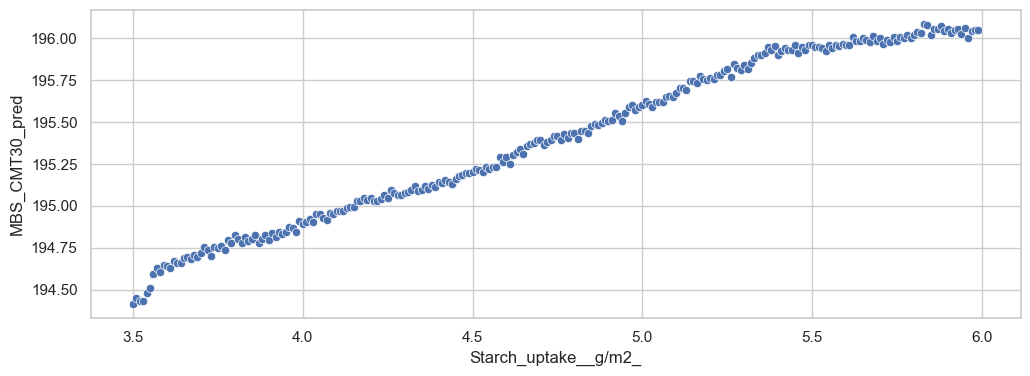

In [95]:
_=sns.scatterplot(newdf, y=target_variable+"_pred", x=control_variable)

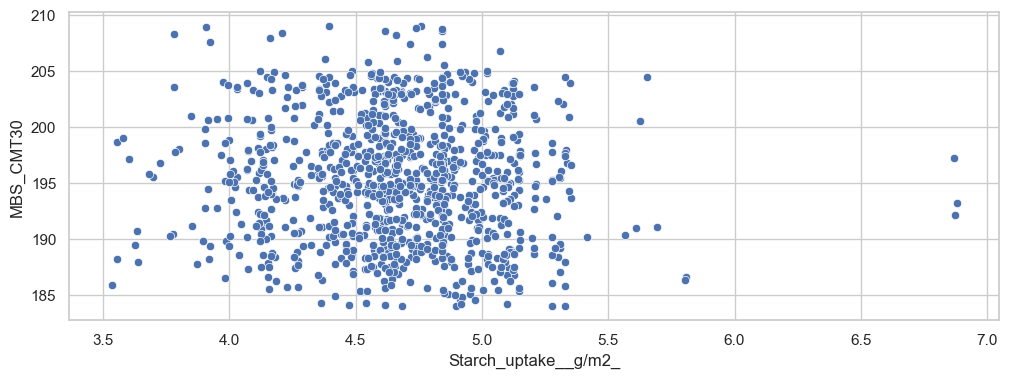

In [80]:
df=joint_distribution_CMT_120.conditional_sample_multi([target_variable, control_variable], df_fixed.drop([target_variable,control_variable],axis=1), n=1000)
_=sns.scatterplot(df, x=control_variable, y=target_variable)

In [70]:
np.corrcoef(df[control_variable],df[target_variable])

array([[ 1.        , -0.07235259],
       [-0.07235259,  1.        ]])